# Python for Finance Cookbook on Iranian markets

Recipes from chapters 1, 2 and 7 of Eryk Lewinson's *Python for Finance Cookbook*
(Packt, 2020), run on TSETMC, TGJU and SCI data through `yfinance_ir` instead of
Yahoo Finance and Quandl. Same recipe names as the book; the market, the calendar
(Saturday to Wednesday, Iranian holidays) and the currency are the differences.

Prices are Rial and adjusted for dividends and capital increases (see
`docs/conventions.md`). Needs an Iranian IP. Outputs below were produced on the
date printed in the first cell.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import datetime as dt
import warnings

import backtrader as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

import yfinance_ir as yf

plt.rcParams["figure.figsize"] = (14, 7)
warnings.simplefilter("ignore", FutureWarning)

START, END = "2017-01-01", None
print("run on", dt.date.today(), "| yfinance_ir", yf.__version__)

run on 2026-09-22 | yfinance_ir 2026.9.0


# Chapter 1: Financial data and preprocessing

## 1.1 Getting data (TSETMC instead of Yahoo Finance)

`Ticker("فولاد").history()` is the `yf.download("AAPL")` of the book. TSETMC also
returns `Last` (last trade, distinct from the closing price), traded `Value` and trade
`Count`; those three columns have no Yahoo equivalent.

In [2]:
folad = yf.Ticker("فولاد")
df = folad.history(start=START, end=END)
print(df.shape)
df.tail()

(2120, 10)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Last,Value,Count
Date,,,,,,,,,,
2026-09-15,3144.0,3239.0,3087.0,3223.0,5.883975e+09,0.0,0.0,3239.0,1.896556e+13,25653.0
2026-09-16,3319.0,3319.0,3251.0,3317.0,9.069143e+09,0.0,0.0,3319.0,3.007974e+13,36087.0
2026-09-19,3410.0,3410.0,3220.0,3300.0,6.500954e+09,0.0,0.0,3280.0,2.145268e+13,78299.0
2026-09-20,3210.0,3280.0,3210.0,3210.0,5.563296e+09,0.0,0.0,3220.0,1.788395e+13,56546.0
2026-09-21,3280.0,3300.0,3200.0,3290.0,3.581143e+09,0.0,0.0,3300.0,1.178593e+13,38289.0


### Crypto from Nobitex

`Ticker("BTC-IRT")` needs the `crypto` extra (`ccxt-ir`). Nobitex quotes `*-IRT` pairs
in Toman; the package keeps them in Toman, so never add a crypto column to a Rial
frame without multiplying by 10. It trades seven days a week, so its calendar is
aligned to TSETMC's by inner join wherever the two meet below.

In [3]:
btc = yf.Ticker("BTC-IRT").history(start=START)
eth = yf.Ticker("ETH-IRT").history(start=START)
print("BTC-IRT", btc.shape, btc.index.min().date(), "->", btc.index.max().date())
print("ETH-IRT", eth.shape, eth.index.min().date(), "->", eth.index.max().date())
btc.tail()

BTC-IRT (487, 7) 2025-05-10 -> 2026-09-21
ETH-IRT (485, 7) 2025-05-10 -> 2026-09-21


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-17,1.738706e+10,1.837364e+10,1.734000e+10,1.828773e+10,14.338891,0.0,0.0
2026-09-18,1.824300e+10,1.869000e+10,1.820500e+10,1.847858e+10,14.419648,0.0,0.0
2026-09-19,1.847858e+10,1.865000e+10,1.825011e+10,1.853761e+10,9.906484,0.0,0.0
2026-09-20,1.859350e+10,1.994000e+10,1.850000e+10,1.994000e+10,20.777686,0.0,0.0
2026-09-21,1.994000e+10,1.994000e+10,1.938600e+10,1.970000e+10,7.897086,0.0,0.0


### Trading calendar

The book hardcodes 252 sessions a year. Tehran trades fewer; measure it from the
data rather than assume it, and reuse the number in every annualisation below.

In [4]:
sessions = df.groupby(df.index.year).size()
N_DAYS = int(round(sessions.iloc[1:-1].mean()))  # drop the partial first and last years
print(sessions.to_dict())
print("sessions per year:", N_DAYS)

{2017: 226, 2018: 236, 2019: 233, 2020: 229, 2021: 226, 2022: 227, 2023: 231, 2024: 226, 2025: 221, 2026: 65}
sessions per year: 229


## 1.2 Converting prices to returns

Simple returns aggregate across assets, log returns across time.

In [5]:
rtn = df[["Close"]].copy()
rtn["simple_rtn"] = rtn["Close"].pct_change()
rtn["log_rtn"] = np.log(rtn["Close"] / rtn["Close"].shift(1))
rtn = rtn.dropna()
rtn.head()

,Close,simple_rtn,log_rtn
Date,,,
2017-01-02,25.804526,0.013343,0.013255
2017-01-03,25.823402,0.000732,0.000731
2017-01-04,26.238691,0.016082,0.015954
2017-01-07,26.408582,0.006475,0.006454
2017-01-08,26.446335,0.001430,0.001429


### There's more: inflation-adjusted returns

The book deflates with US CPI from Quandl. `Ticker("CPI")` is the Statistical Centre of
Iran index, one row per Jalali month stamped on the month's first day, so it is
forward-filled onto month ends before dividing.

In [6]:
cpi = yf.Ticker("CPI").history(start=START)["Close"]
monthly = df["Close"].resample("ME").last().to_frame("Close")
monthly["cpi"] = cpi.reindex(monthly.index, method="ffill")
monthly["simple_rtn"] = monthly["Close"].pct_change()
monthly["inflation"] = monthly["cpi"].pct_change()
monthly["real_rtn"] = (1 + monthly["simple_rtn"]) / (1 + monthly["inflation"]) - 1
monthly = monthly.dropna()

total = (1 + monthly[["simple_rtn", "real_rtn"]]).prod() - 1
print(total.map("{:+.1%}".format))
monthly.tail()

simple_rtn    +11274.0%
real_rtn        +508.2%
dtype: str


,Close,cpi,simple_rtn,inflation,real_rtn
Date,,,,,
2025-11-30,2406.220305,435.084401,0.095715,0.042013,0.051537
2025-12-31,3077.017766,469.363895,0.278776,0.078788,0.185382
2026-01-31,2491.967039,513.637392,-0.190136,0.094327,-0.259943
2026-02-28,2548.878589,542.341434,0.022838,0.055884,-0.031297
2026-09-30,3290.000000,700.130356,0.186869,0.000000,0.186869


### There's more: returns in dollars, and against bitcoin

`Ticker("USD")` is TGJU's free-market dollar in Rial. Dividing the Rial series by it
gives the stock in dollars on every trading day. Bitcoin in Toman is divided by the same
dollar (over 10, Toman to Rial) to put both on one axis.

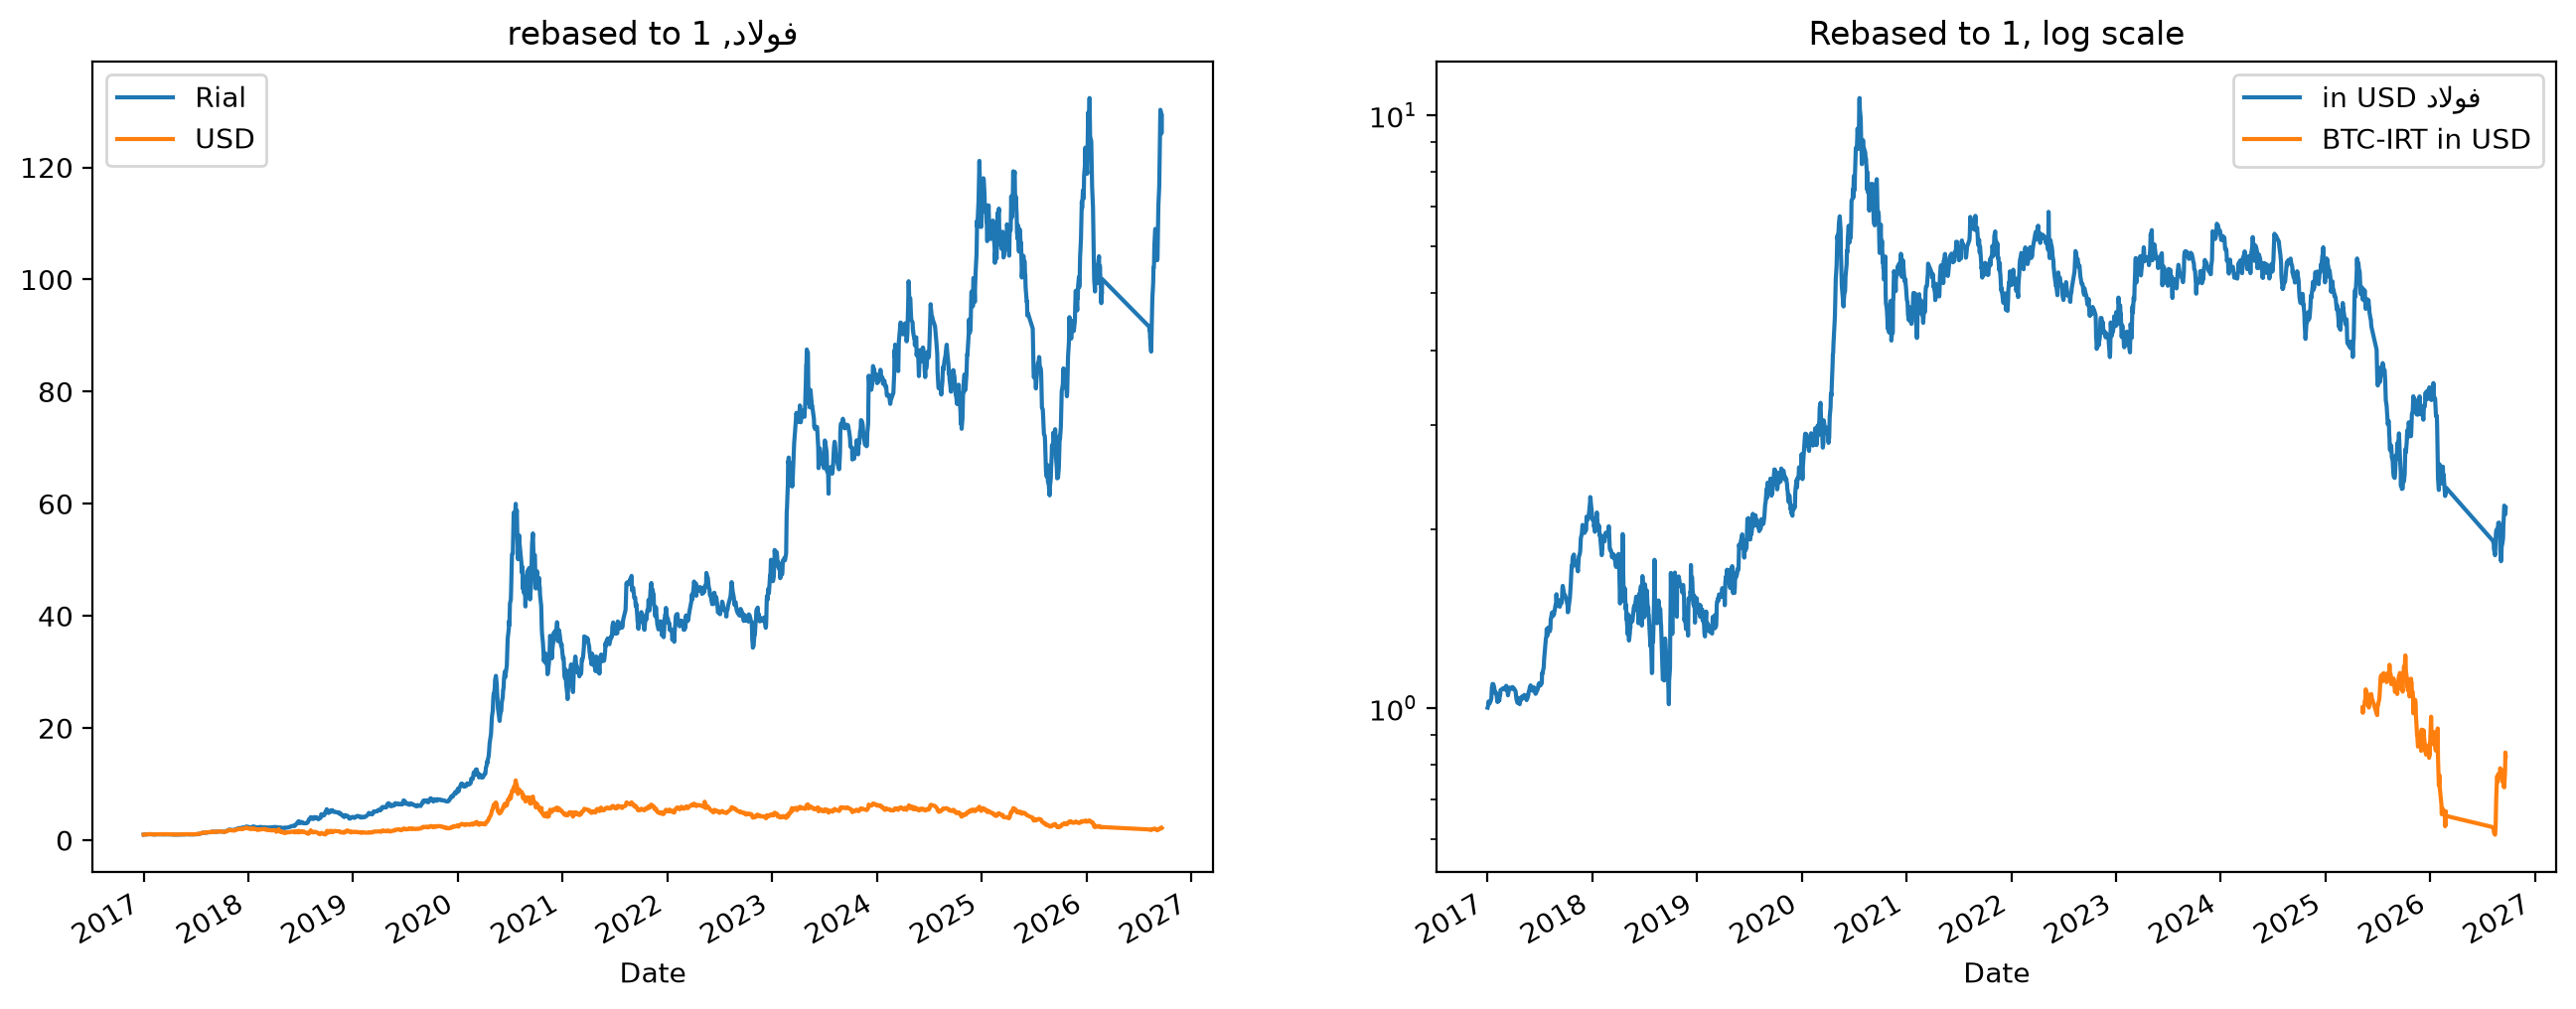

In [7]:
usd = yf.Ticker("USD").history(start=START)["Close"].reindex(df.index, method="ffill")
in_usd = df["Close"] / usd
btc_usd = (btc["Close"] * 10 / usd).dropna()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
(df["Close"] / df["Close"].iloc[0]).plot(ax=ax[0], label="Rial")
(in_usd / in_usd.iloc[0]).plot(ax=ax[0], label="USD")
ax[0].set_title("فولاد, rebased to 1")
ax[0].legend()
(in_usd / in_usd.iloc[0]).plot(ax=ax[1], label="فولاد in USD")
(btc_usd / btc_usd.iloc[0]).plot(ax=ax[1], label="BTC-IRT in USD")
ax[1].set_yscale("log")
ax[1].set_title("Rebased to 1, log scale")
ax[1].legend()
plt.show()

## 1.3 Changing frequency

Monthly realised volatility from daily log returns, annualised with the measured
session count instead of 252.

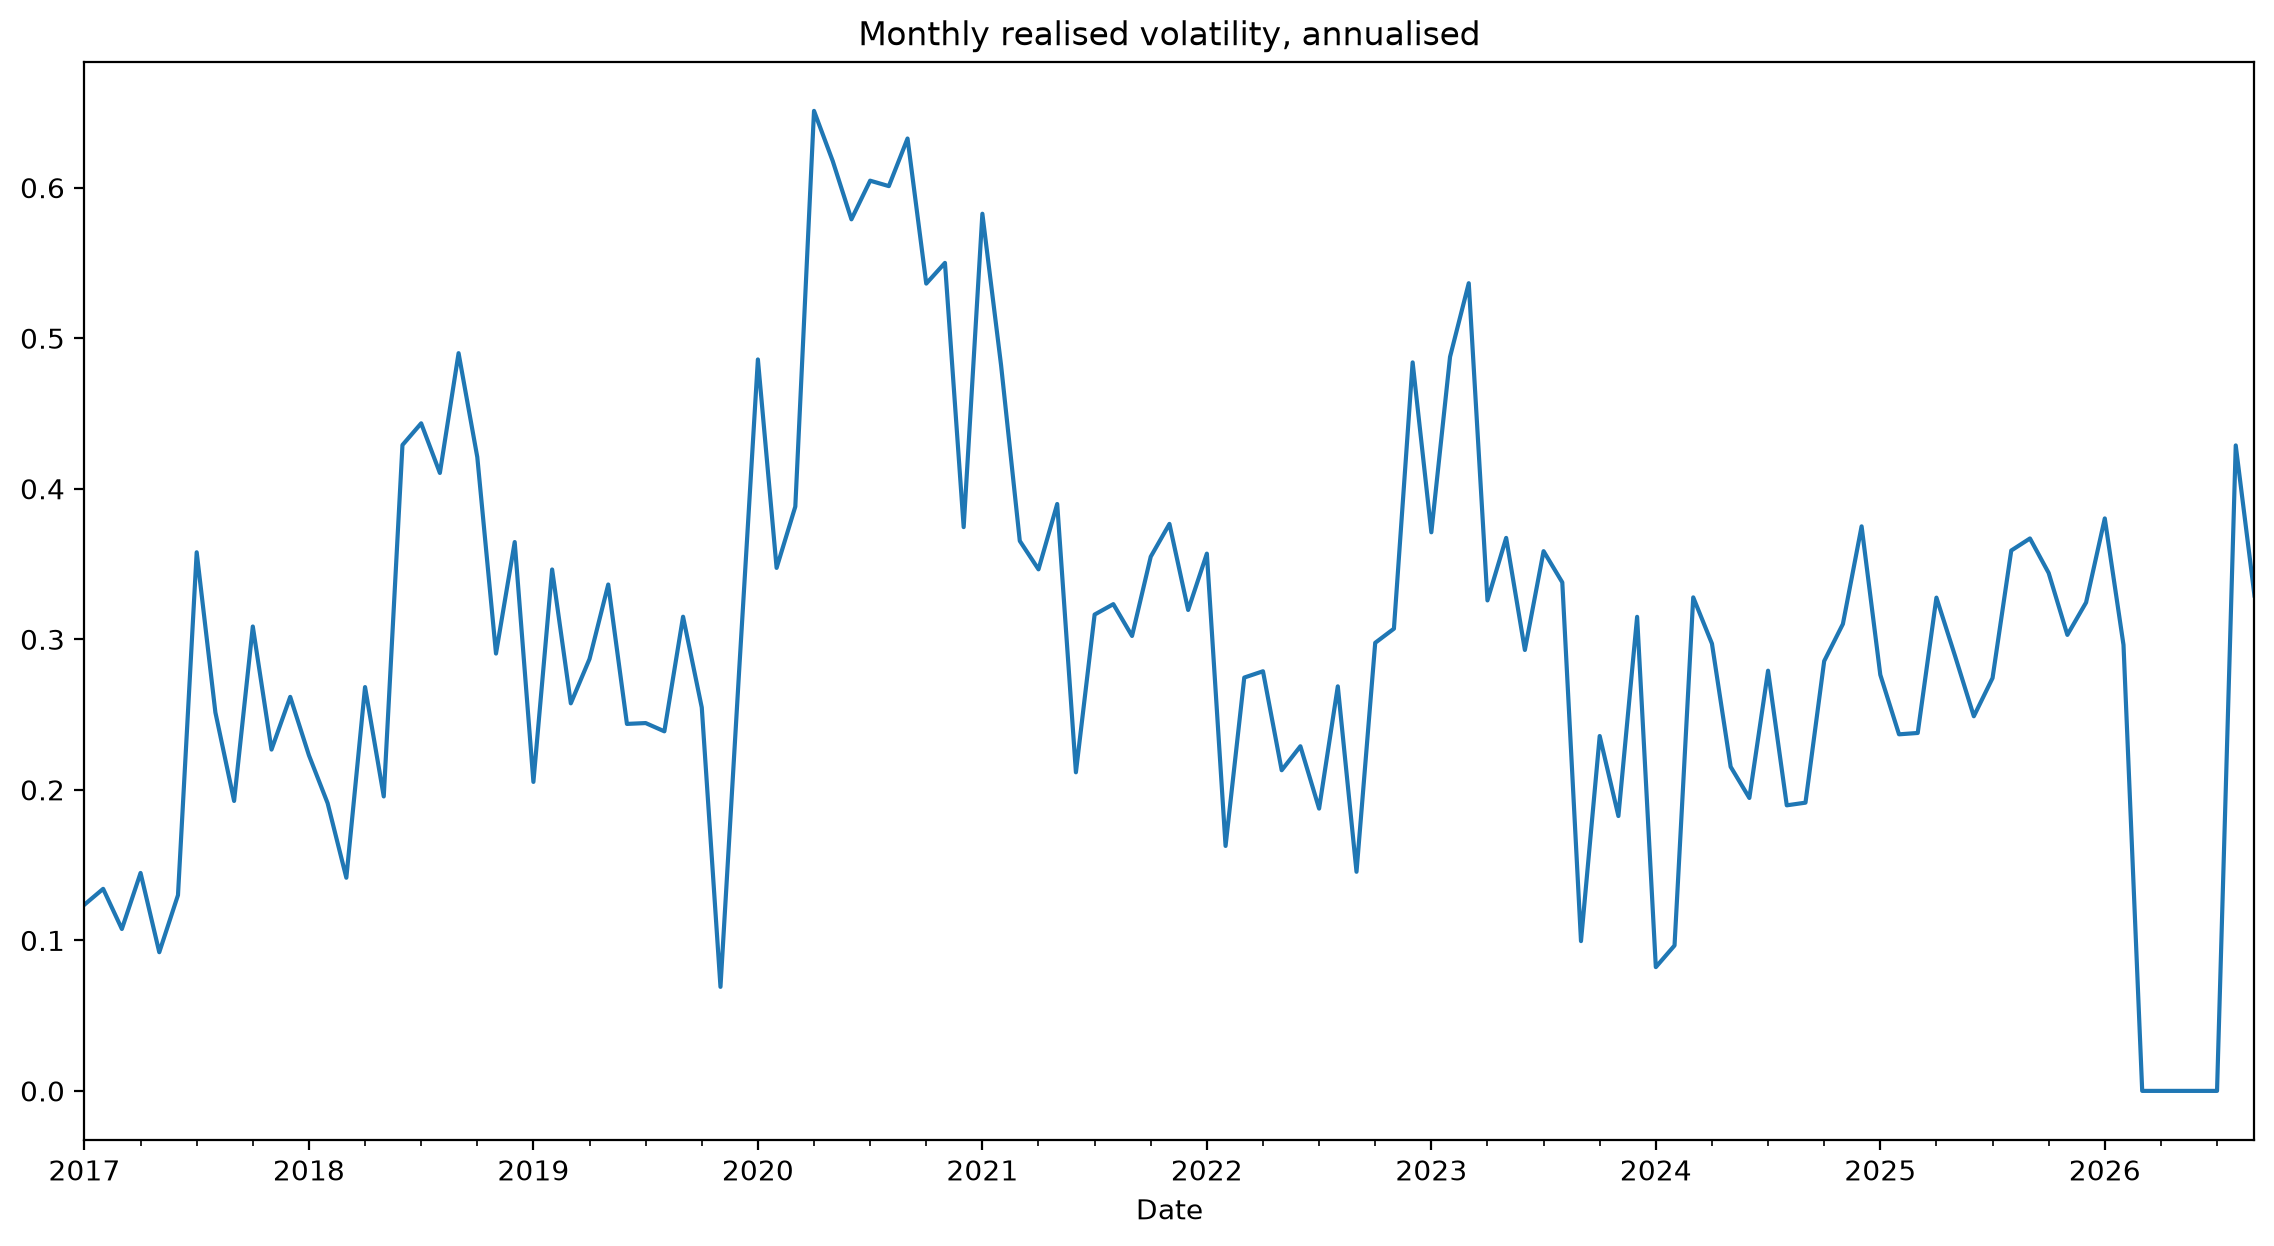

In [8]:
def realized_volatility(x):
    return np.sqrt(np.sum(x ** 2))

rv = rtn["log_rtn"].resample("ME").apply(realized_volatility).to_frame("rv")
rv["rv_annual"] = rv["rv"] * np.sqrt(12)
rv["rv_annual"].plot(title="Monthly realised volatility, annualised")
plt.show()

## 1.4 Visualising time series data

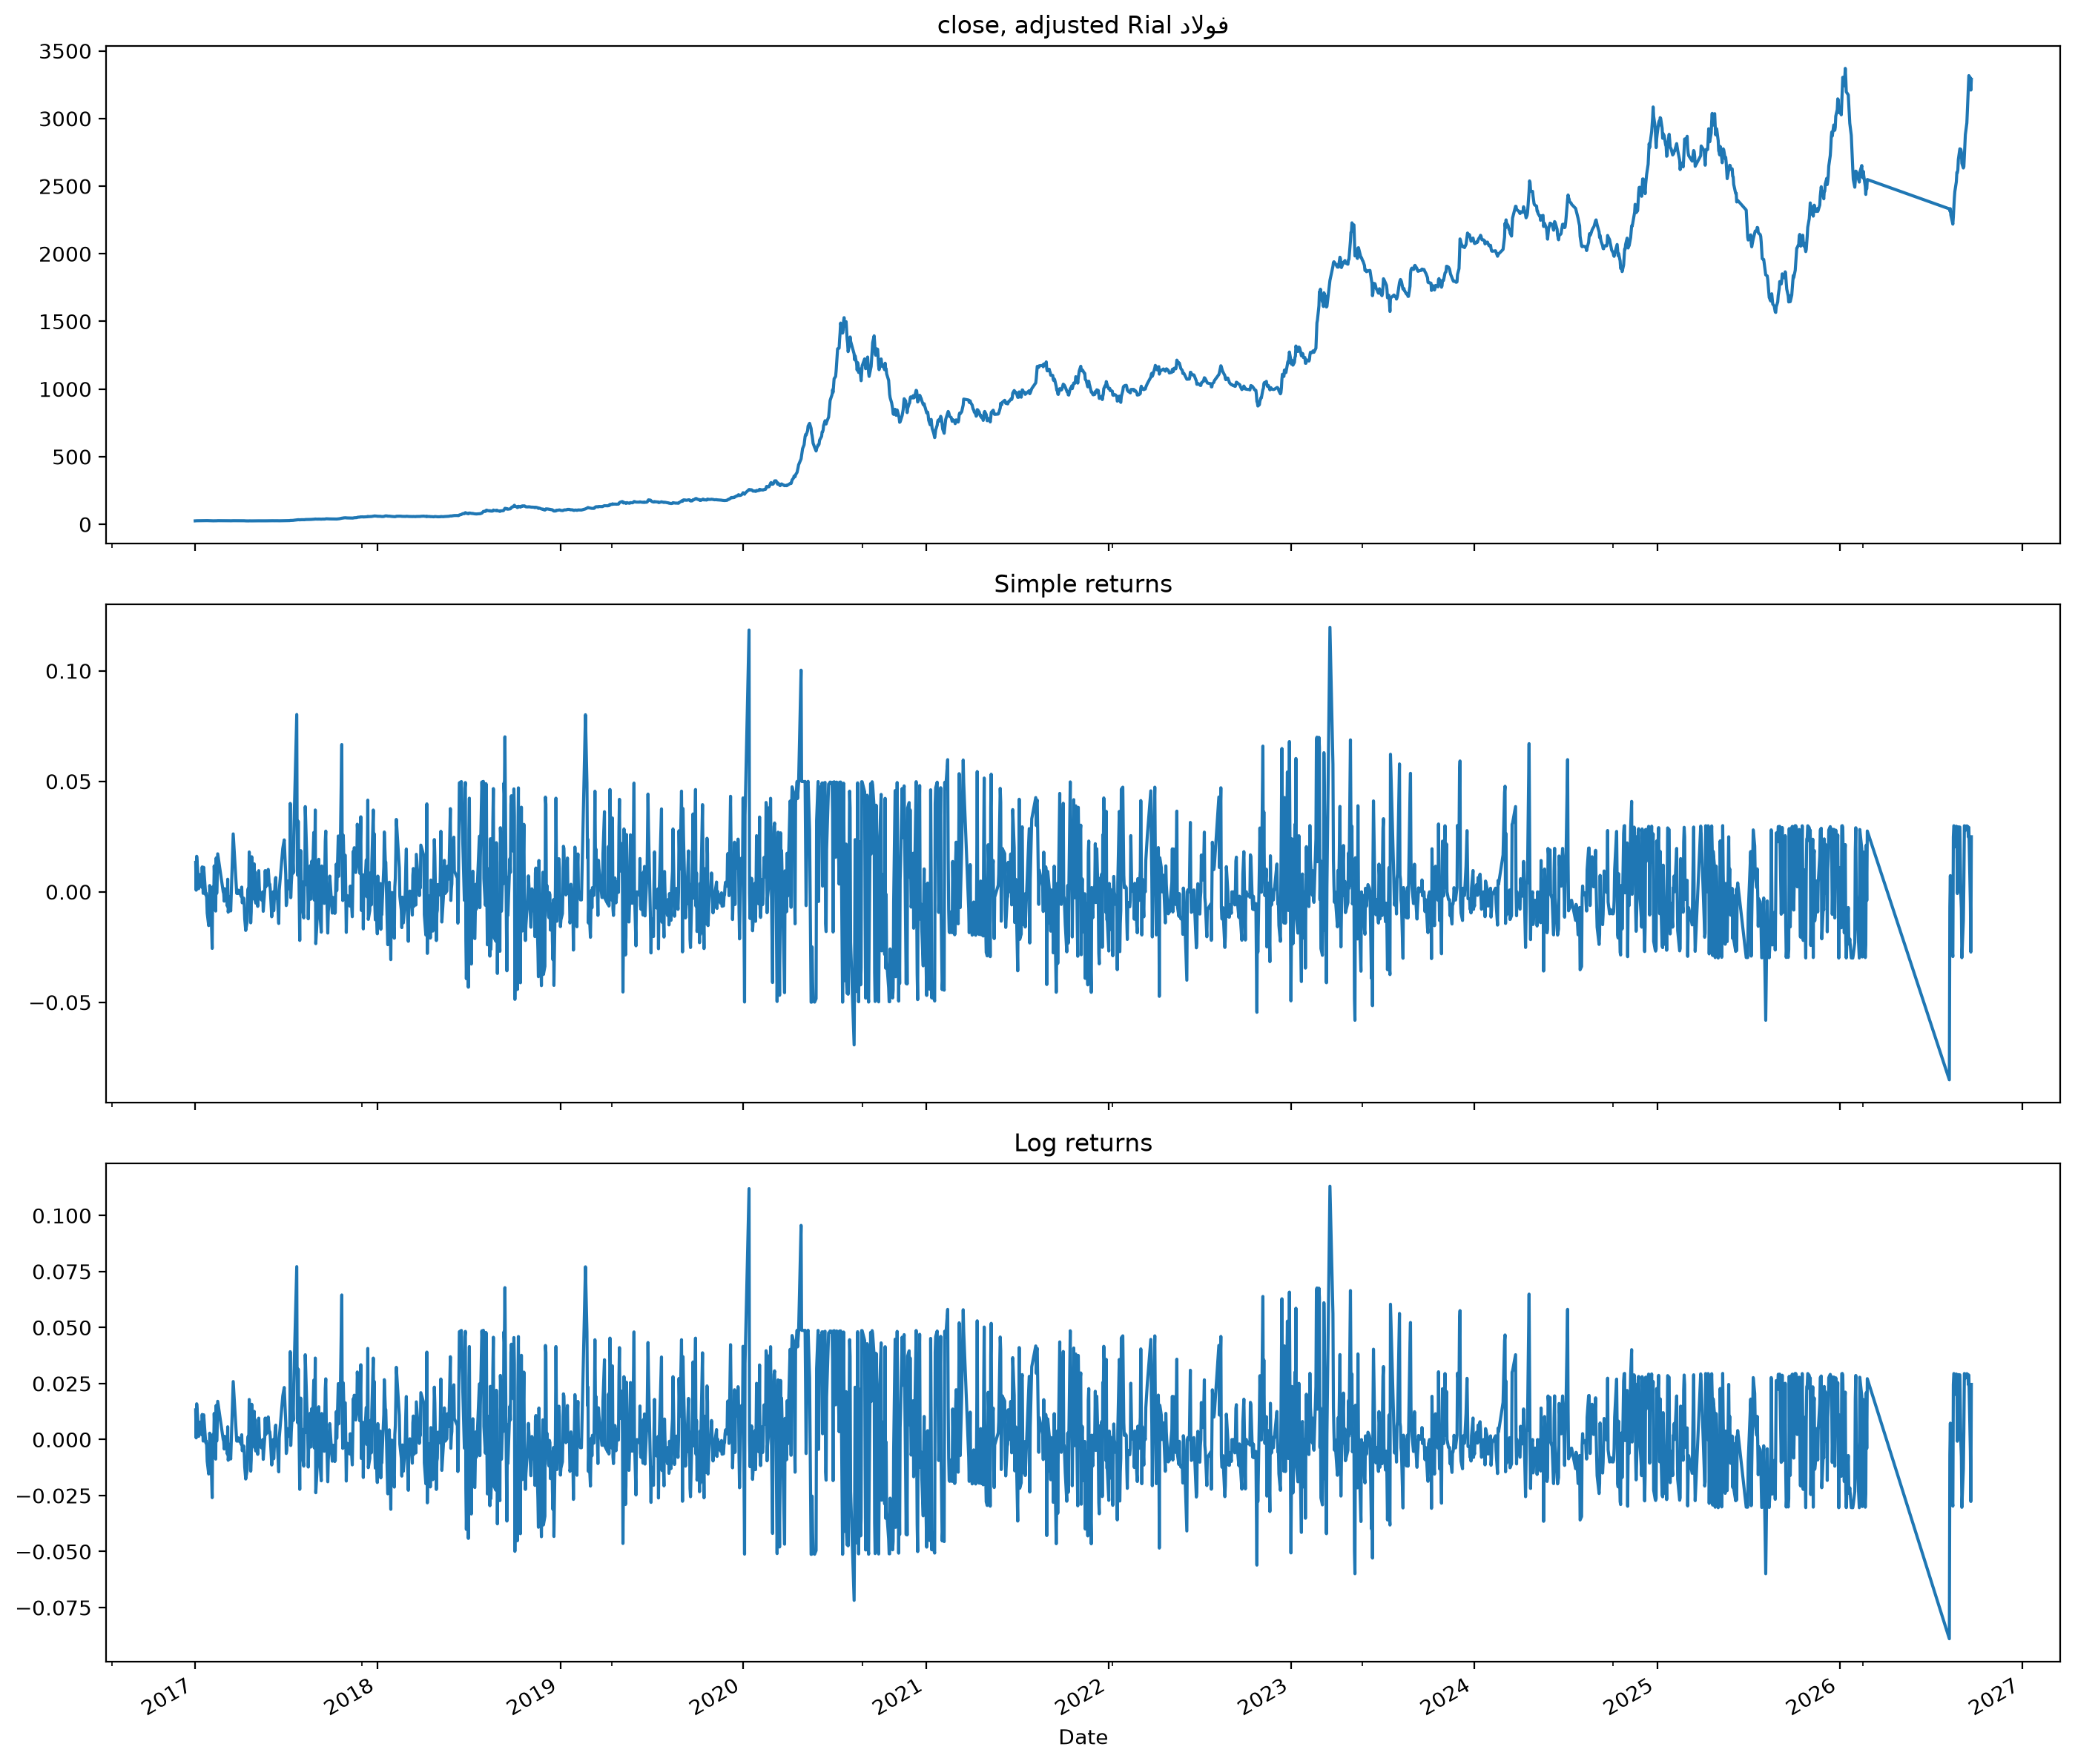

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
df["Close"].plot(ax=ax[0], title="فولاد close, adjusted Rial")
rtn["simple_rtn"].plot(ax=ax[1], title="Simple returns")
rtn["log_rtn"].plot(ax=ax[2], title="Log returns")
plt.tight_layout()
plt.show()

## 1.5 Identifying outliers

The 3σ rule on a 21-session rolling window, as in the book.

11 outliers


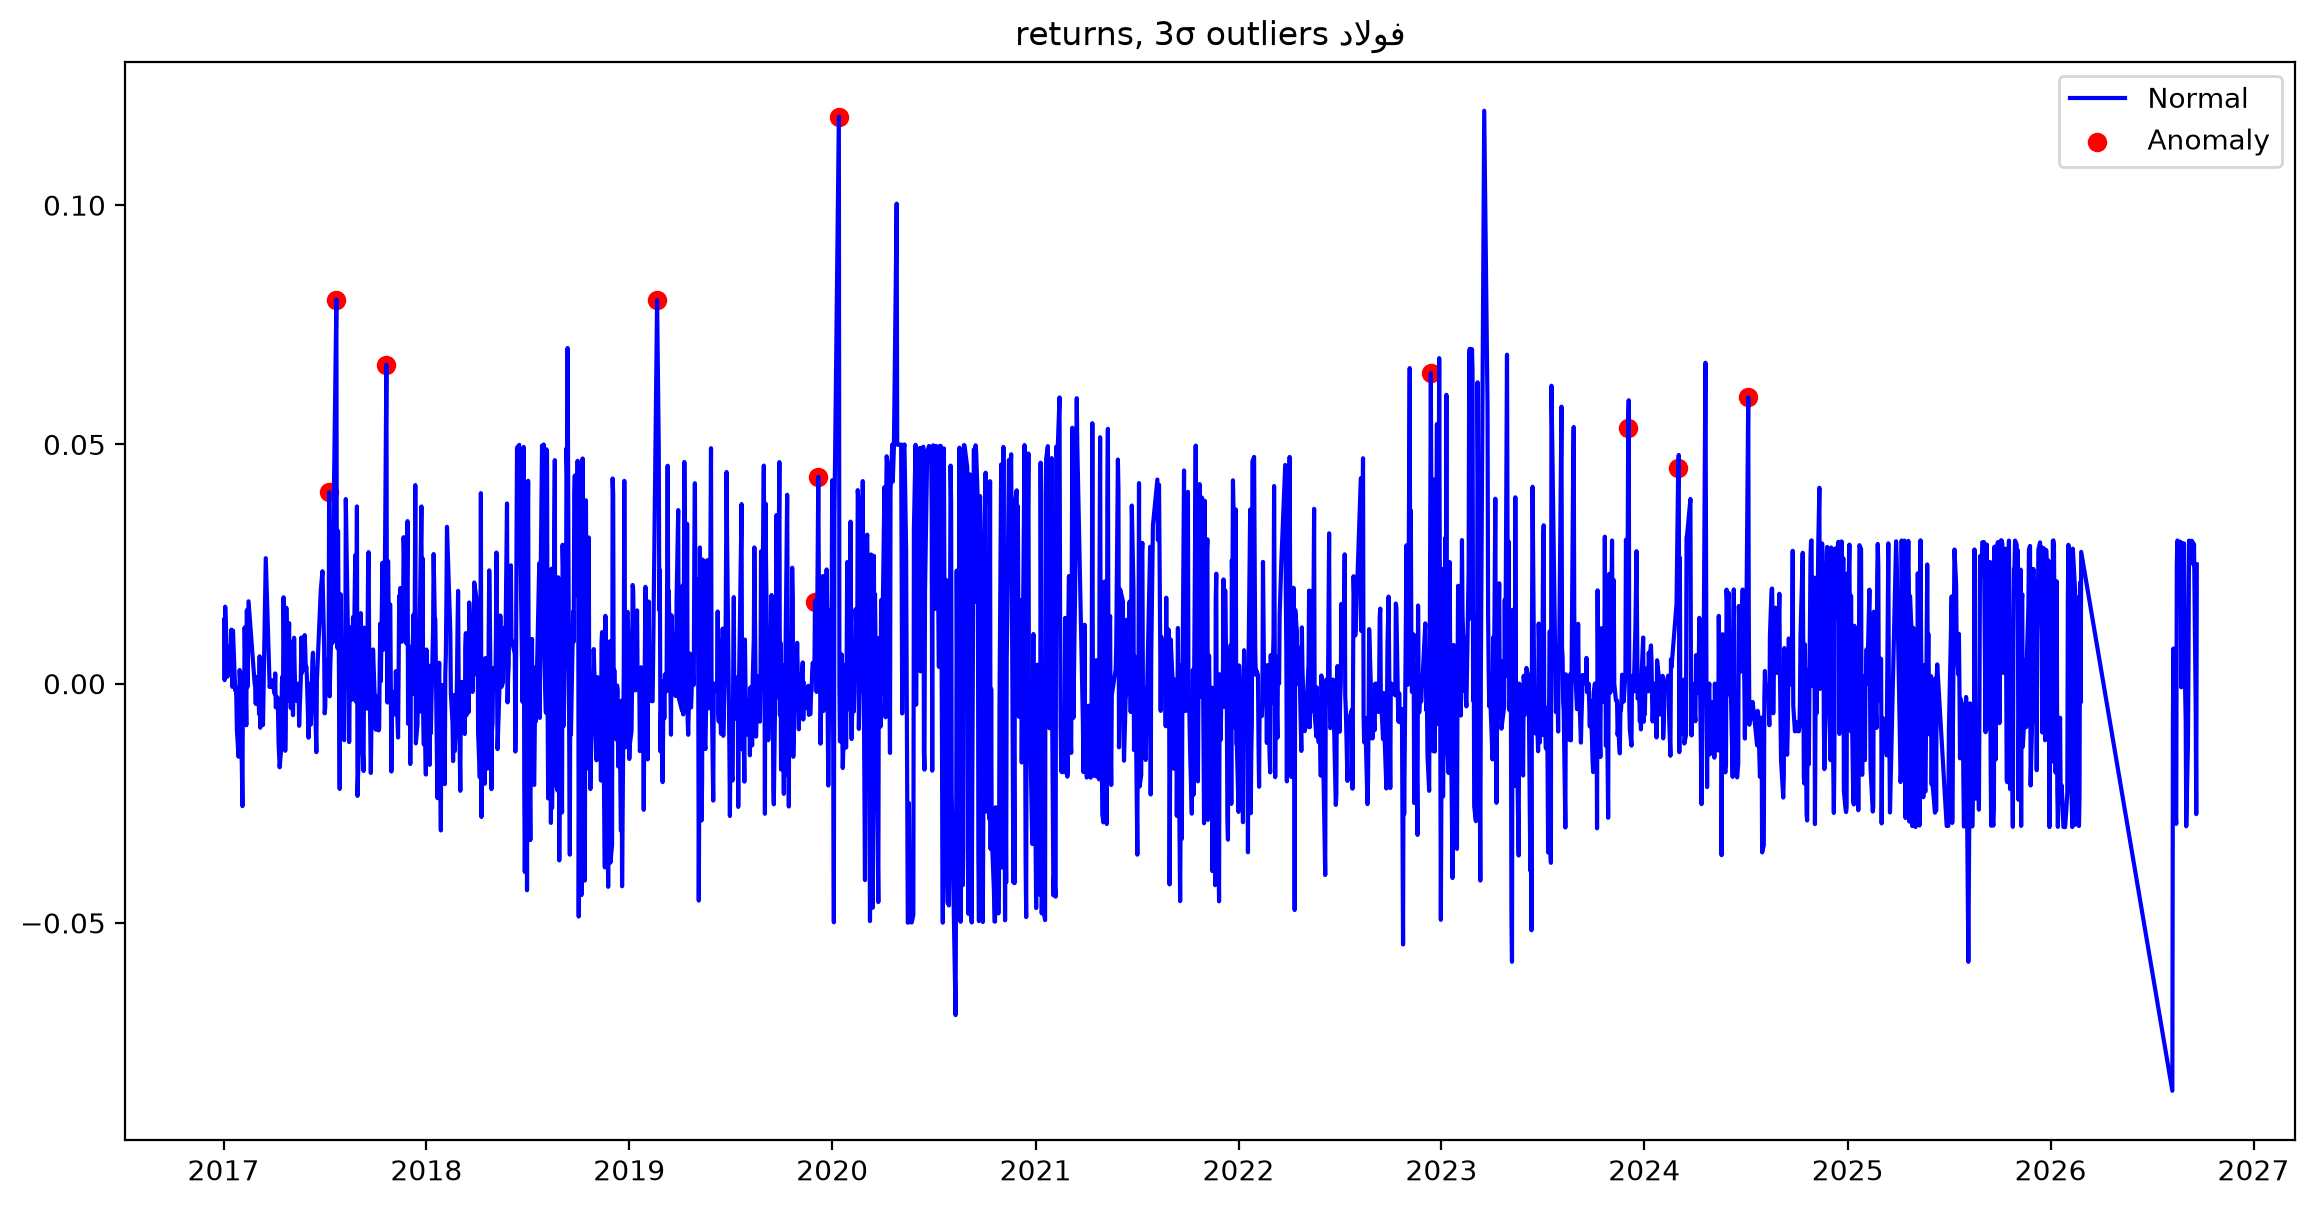

In [10]:
roll = rtn[["simple_rtn"]].rolling(window=21).agg(["mean", "std"])
roll.columns = roll.columns.droplevel()
out = rtn.join(roll)

def is_outlier(row, n_sigmas=3):
    x, mu, sigma = row["simple_rtn"], row["mean"], row["std"]
    return 1 if (x > mu + n_sigmas * sigma) or (x < mu - n_sigmas * sigma) else 0

out["outlier"] = out.apply(is_outlier, axis=1)
outliers = out.loc[out["outlier"] == 1, ["simple_rtn"]]
print(len(outliers), "outliers")

fig, ax = plt.subplots()
ax.plot(out.index, out["simple_rtn"], color="blue", label="Normal")
ax.scatter(outliers.index, outliers["simple_rtn"], color="red", label="Anomaly")
ax.set_title("فولاد returns, 3σ outliers")
ax.legend()
plt.show()

## 1.6 Stylised facts of asset returns

### Fact 1: non-Gaussian distribution

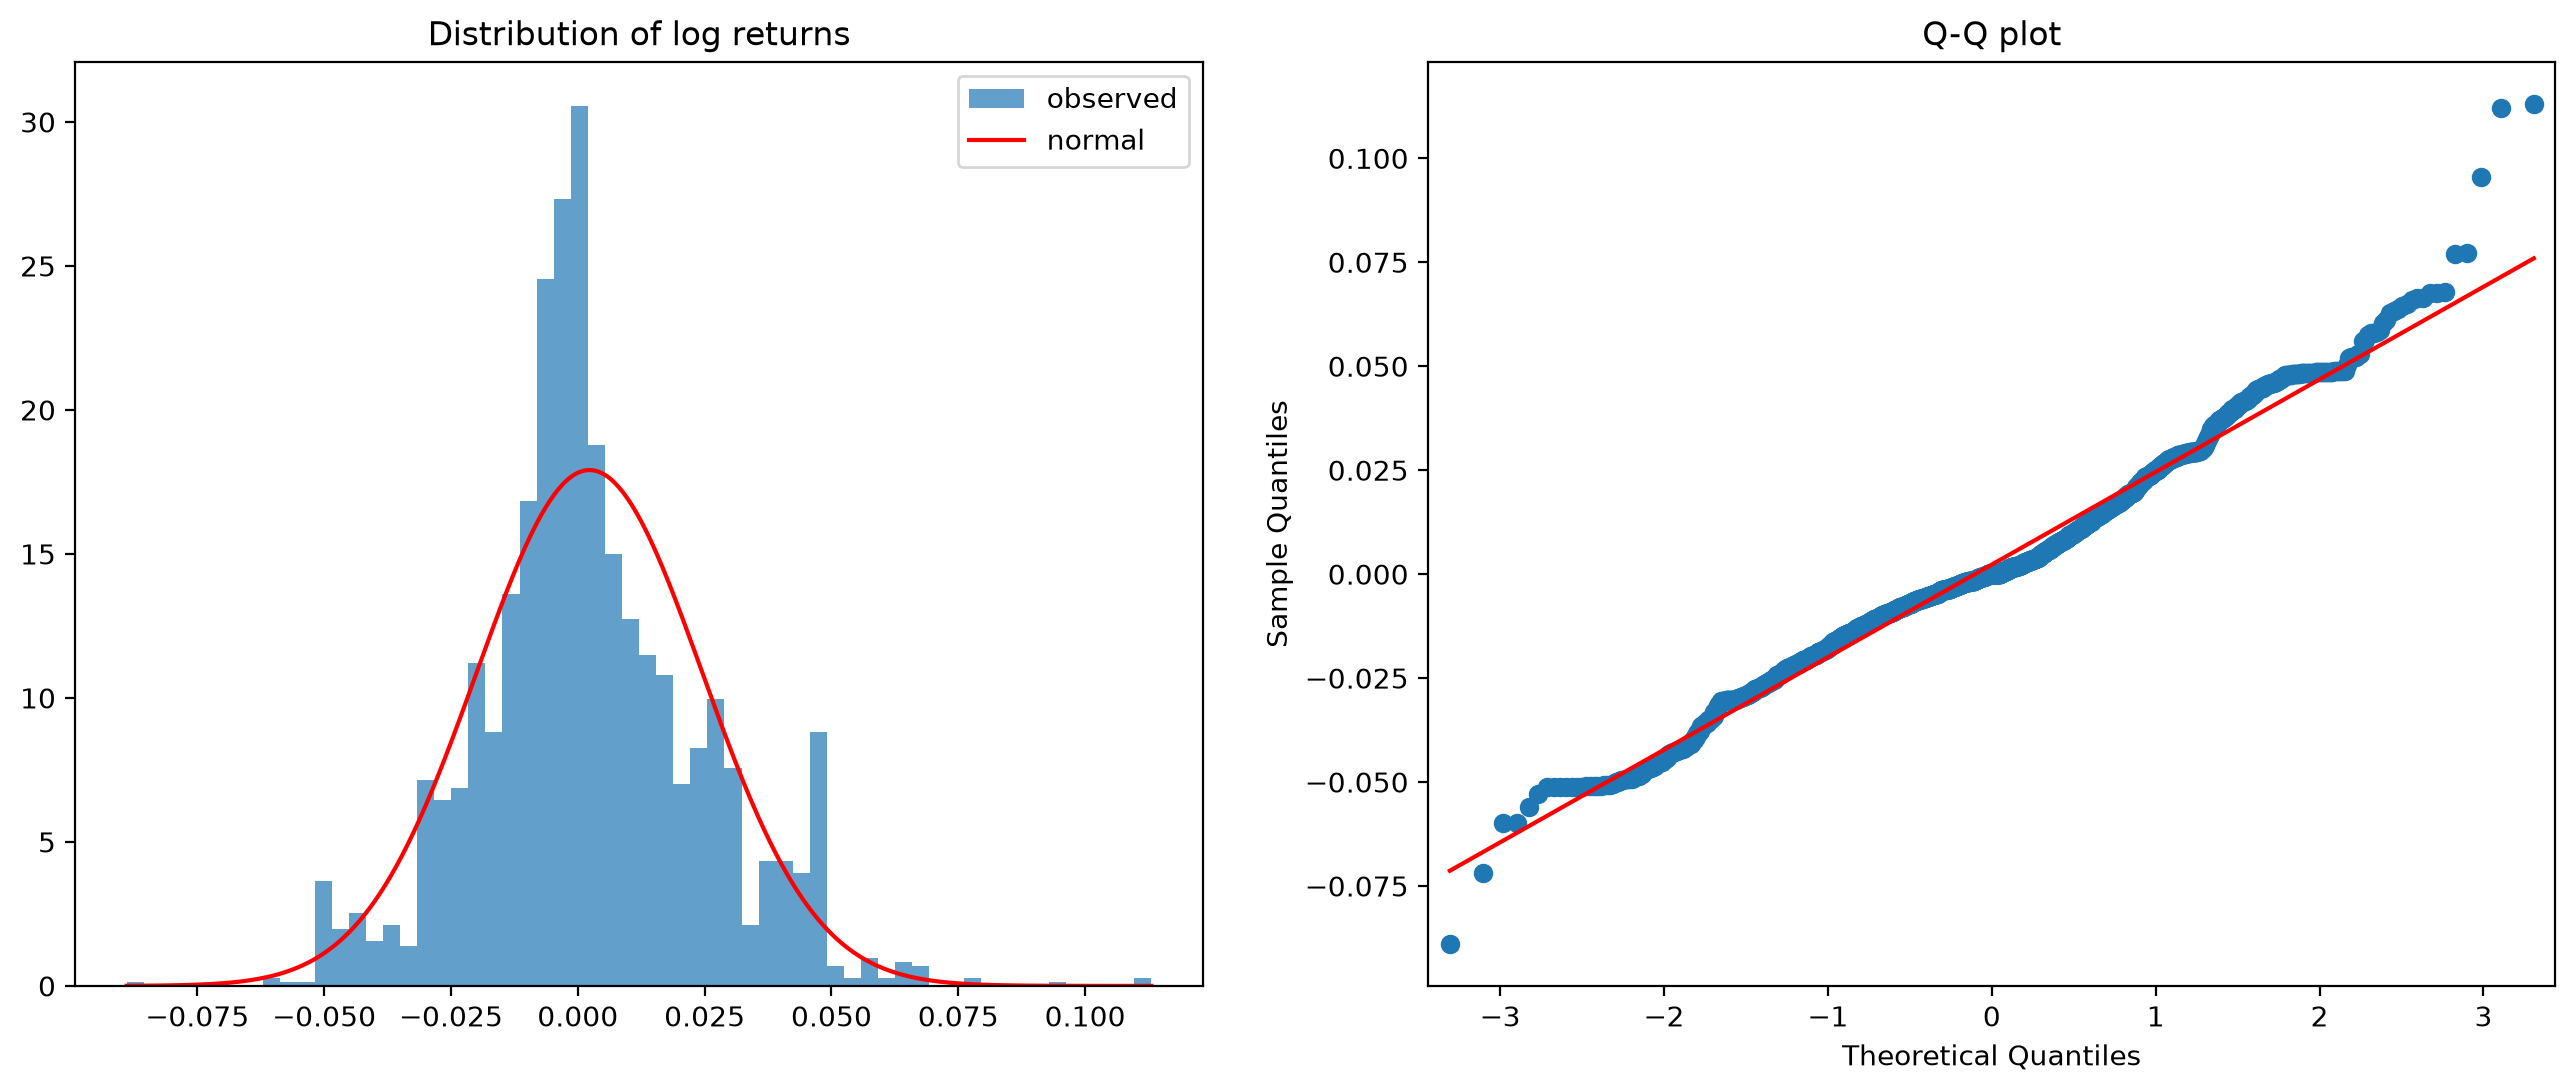

skew 0.33, kurtosis 0.95
Jarque-Bera p-value: 1.859170005165771e-26


In [11]:
r = rtn["log_rtn"]
mu, sigma = r.mean(), r.std()
x = np.linspace(r.min(), r.max(), 500)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].hist(r, bins=60, density=True, alpha=0.7, label="observed")
ax[0].plot(x, scs.norm.pdf(x, mu, sigma), "r", label="normal")
ax[0].set_title("Distribution of log returns")
ax[0].legend()
sm.qqplot(r.values, line="s", ax=ax[1])
ax[1].set_title("Q-Q plot")
plt.show()

print(f"skew {scs.skew(r):.2f}, kurtosis {scs.kurtosis(r):.2f}")
print("Jarque-Bera p-value:", scs.jarque_bera(r)[1])

In [12]:
jb_stat, jb_p = scs.jarque_bera(r)
excess_kurt = scs.kurtosis(r)
tails = pd.DataFrame(
    {f"|r| > {k} sigma": [int((r.abs() > k * sigma).sum()), 2 * scs.norm.sf(k) * len(r)]
     for k in (3, 5, 10)},
    index=["observed", "a normal would give"],
).T.round(2)
print(tails)
print(f"\nskew {scs.skew(r):+.2f} | excess kurtosis {excess_kurt:+.2f}"
      f" | Jarque-Bera {jb_stat:,.0f} (p={jb_p:.1e})")

                observed  a normal would give
|r| > 3 sigma       10.0                 5.72
|r| > 5 sigma        2.0                 0.00
|r| > 10 sigma       0.0                 0.00

skew +0.33 | excess kurtosis +0.95 | Jarque-Bera 118 (p=1.9e-26)


### Fact 2: volatility clustering

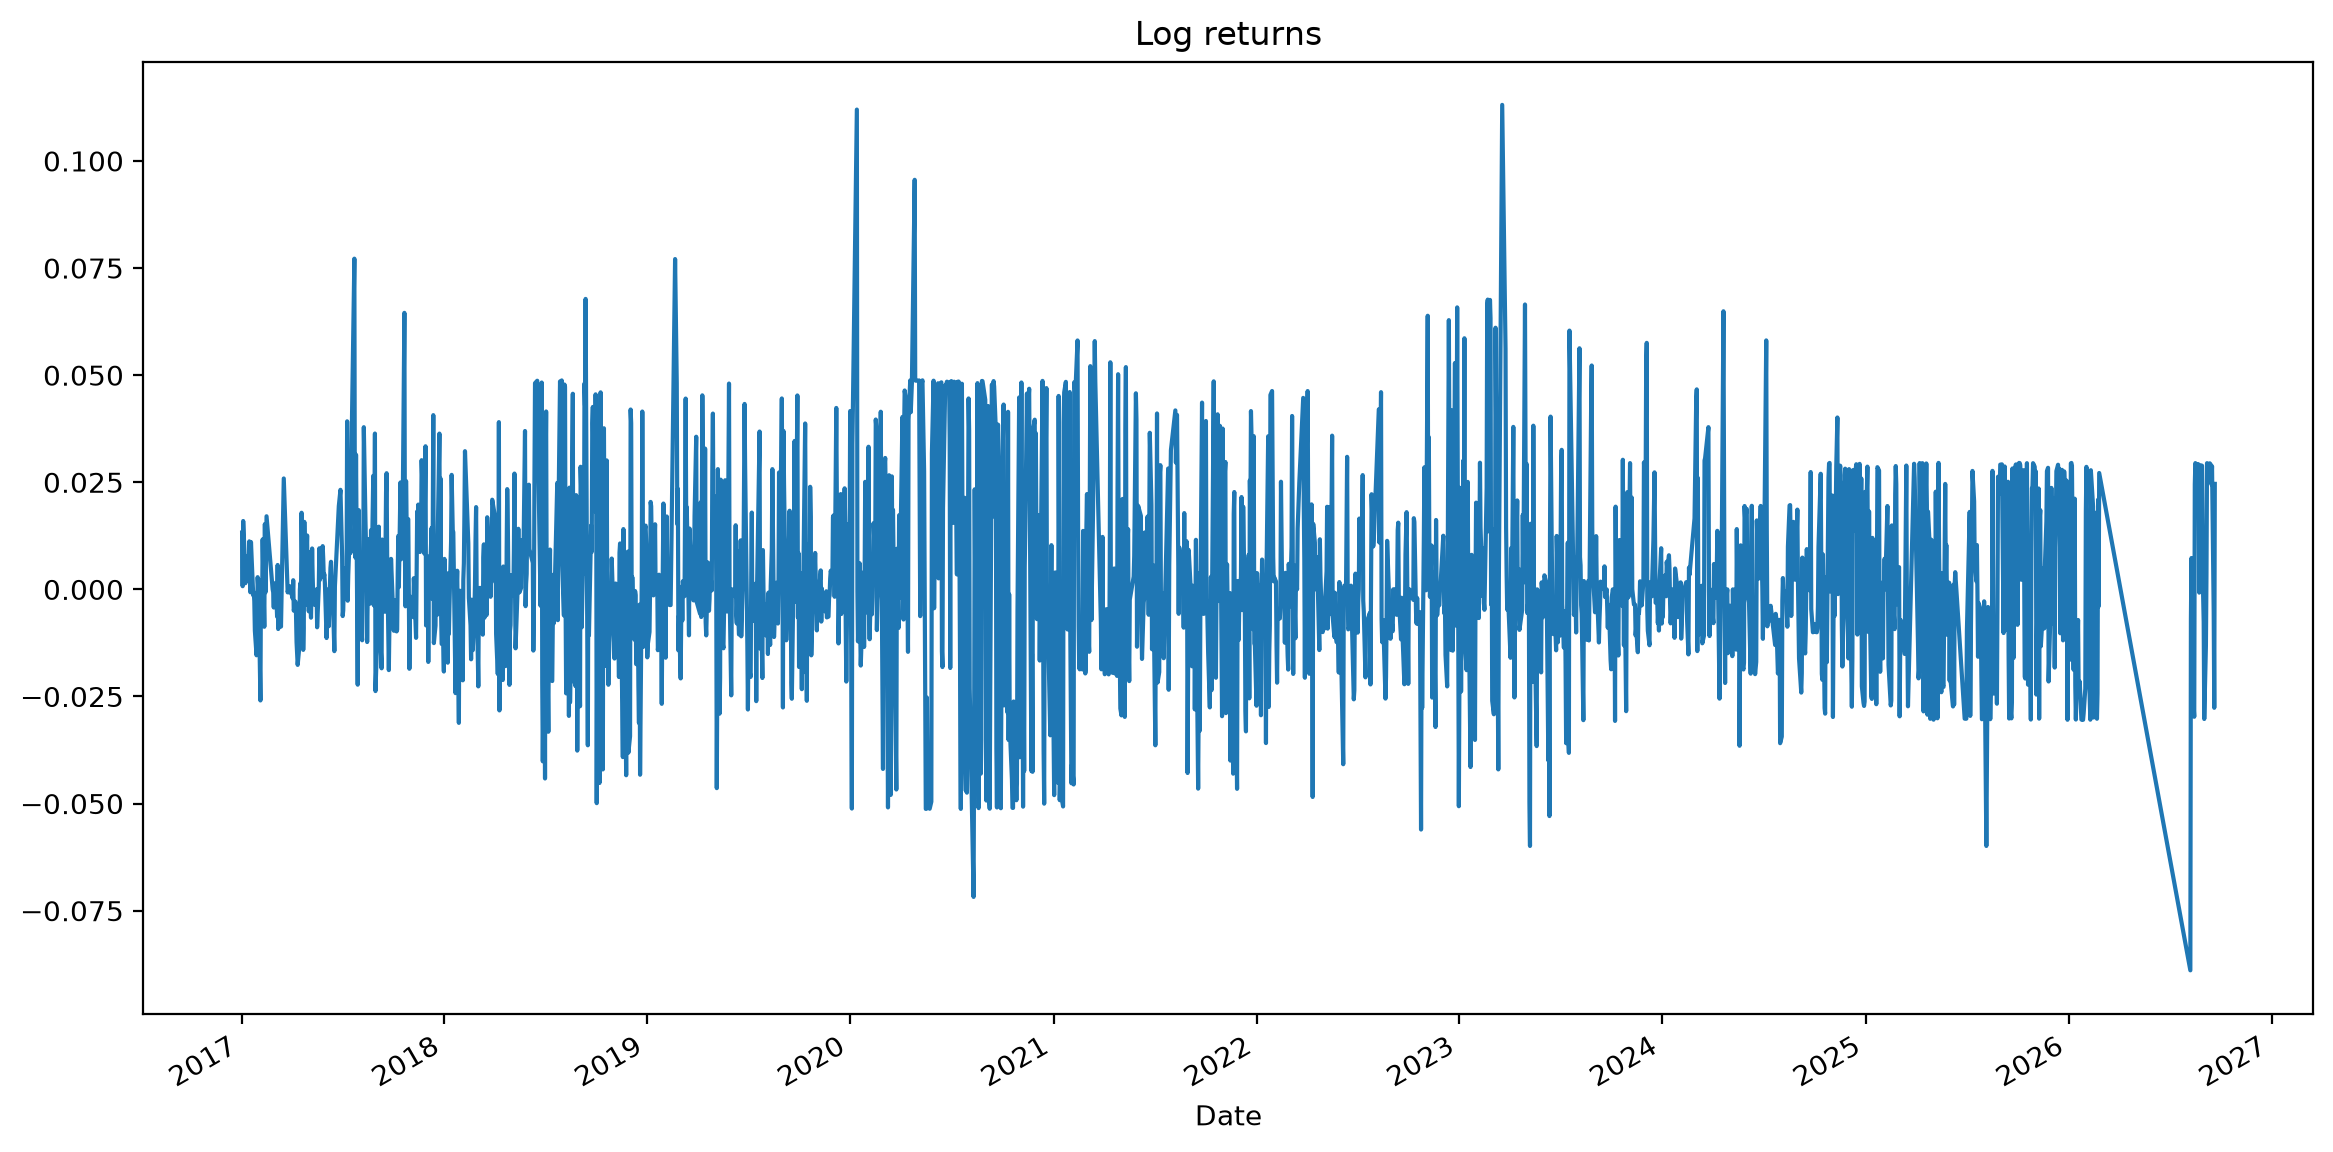

In [13]:
r.plot(title="Log returns")
plt.show()

In [14]:
arch_stat, arch_p, _, _ = het_arch(r, nlags=12)
print(f"Engle ARCH(12): LM {arch_stat:,.1f}, p={arch_p:.2e}")

vol21 = r.rolling(21).std().dropna()
calm, wild = vol21.quantile(0.1), vol21.quantile(0.9)
print(f"21-session volatility: calmest decile {calm:.3%}, wildest decile {wild:.3%},"
      f" ratio {wild / calm:.1f}x")

Engle ARCH(12): LM 281.3, p=3.85e-53
21-session volatility: calmest decile 1.155%, wildest decile 3.046%, ratio 2.6x


### Fact 3: no autocorrelation in returns

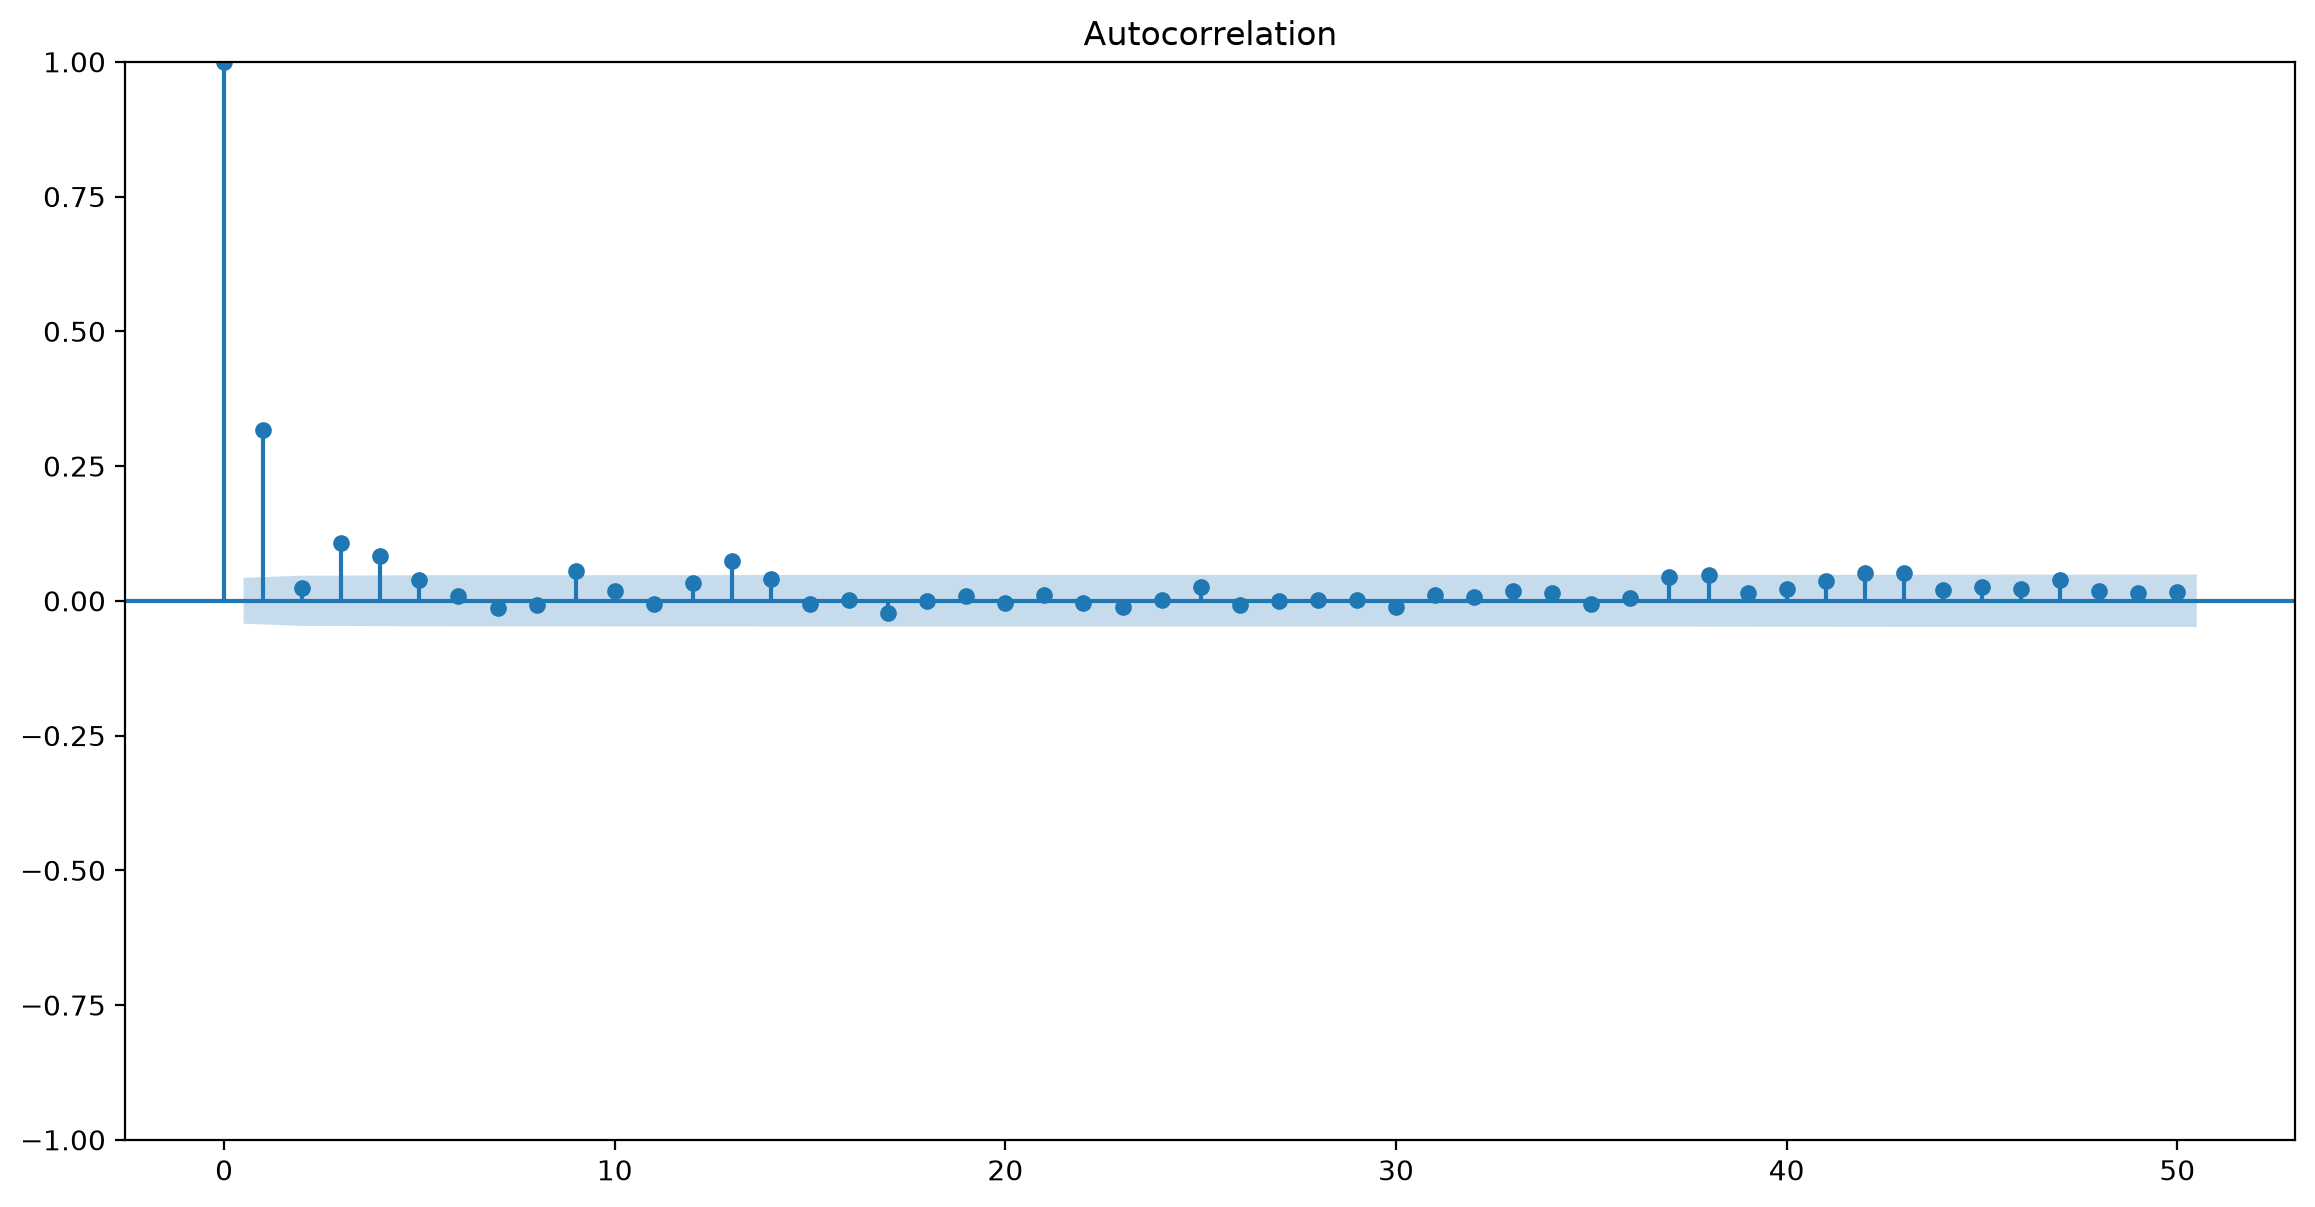

In [15]:
smt.graphics.plot_acf(r, lags=50, alpha=0.05)
plt.show()

In [16]:
lb = acorr_ljungbox(r, lags=[5, 10, 20, 50], return_df=True)
lb_returns = lb["lb_pvalue"].loc[20]
print(lb.round(4))

     lb_stat  lb_pvalue
5   257.5430        0.0
10  265.4608        0.0
20  284.0261        0.0
50  321.4350        0.0


### Fact 4: small, slowly decaying autocorrelation in squared and absolute returns

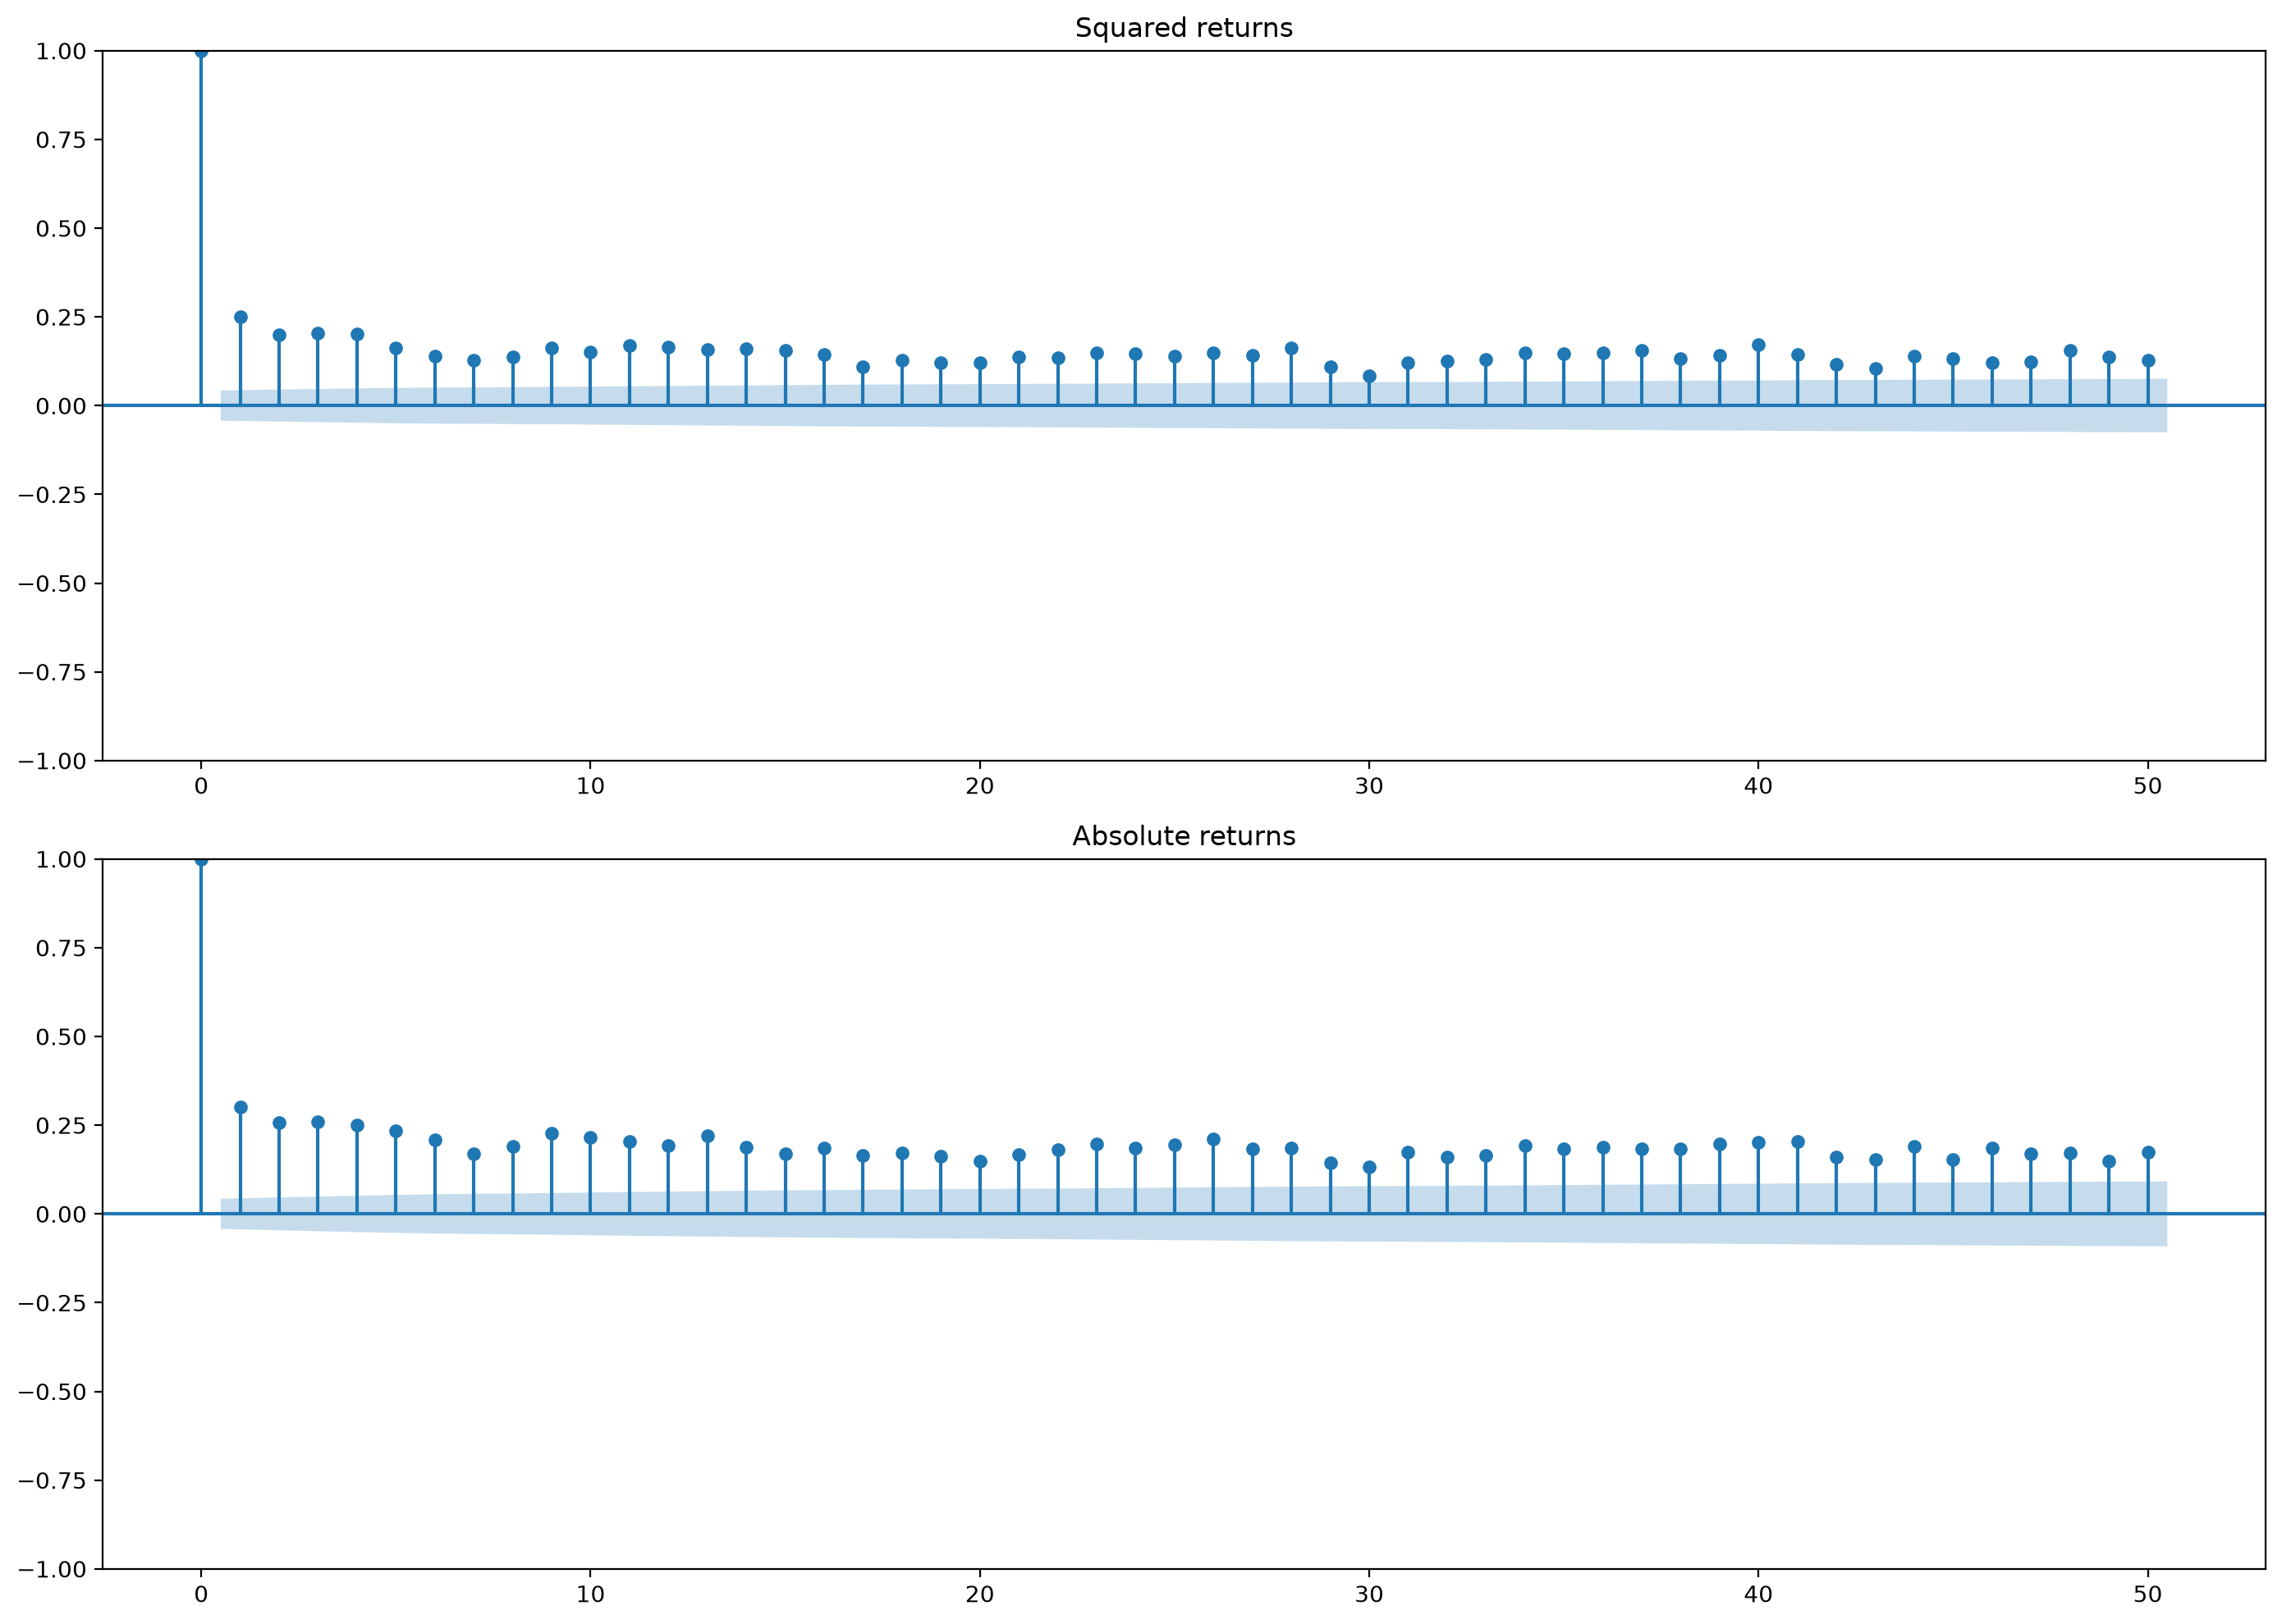

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
smt.graphics.plot_acf(r ** 2, lags=50, alpha=0.05, ax=ax[0])
ax[0].set_title("Squared returns")
smt.graphics.plot_acf(np.abs(r), lags=50, alpha=0.05, ax=ax[1])
ax[1].set_title("Absolute returns")
plt.tight_layout()
plt.show()

In [18]:
acf_raw = sm.tsa.acf(r, nlags=50)
acf_sq = sm.tsa.acf(r ** 2, nlags=50)
acf_abs = sm.tsa.acf(np.abs(r), nlags=50)
ci = 1.96 / np.sqrt(len(r))
lags = [1, 5, 10, 20, 50]
print(pd.DataFrame({"raw": acf_raw[lags], "squared": acf_sq[lags], "absolute": acf_abs[lags]},
                   index=[f"lag {k}" for k in lags]).round(3))
print(f"95% white-noise band: +/-{ci:.3f}")
lb_sq = acorr_ljungbox(r ** 2, lags=[20], return_df=True)["lb_pvalue"].iloc[0]
print(f"Ljung-Box(20) on squared returns: p={lb_sq:.2e}")

          raw  squared  absolute
lag 1   0.317    0.250     0.302
lag 5   0.039    0.162     0.233
lag 10  0.017    0.152     0.215
lag 20 -0.004    0.120     0.149
lag 50  0.016    0.127     0.173
95% white-noise band: +/-0.043
Ljung-Box(20) on squared returns: p=1.10e-222


### Fact 5: leverage effect

The book compares returns with a 252-day rolling volatility; here it is the measured
session count. A negative correlation between returns and later volatility is the
leverage effect; the correlation printed below says whether this stock shows one.

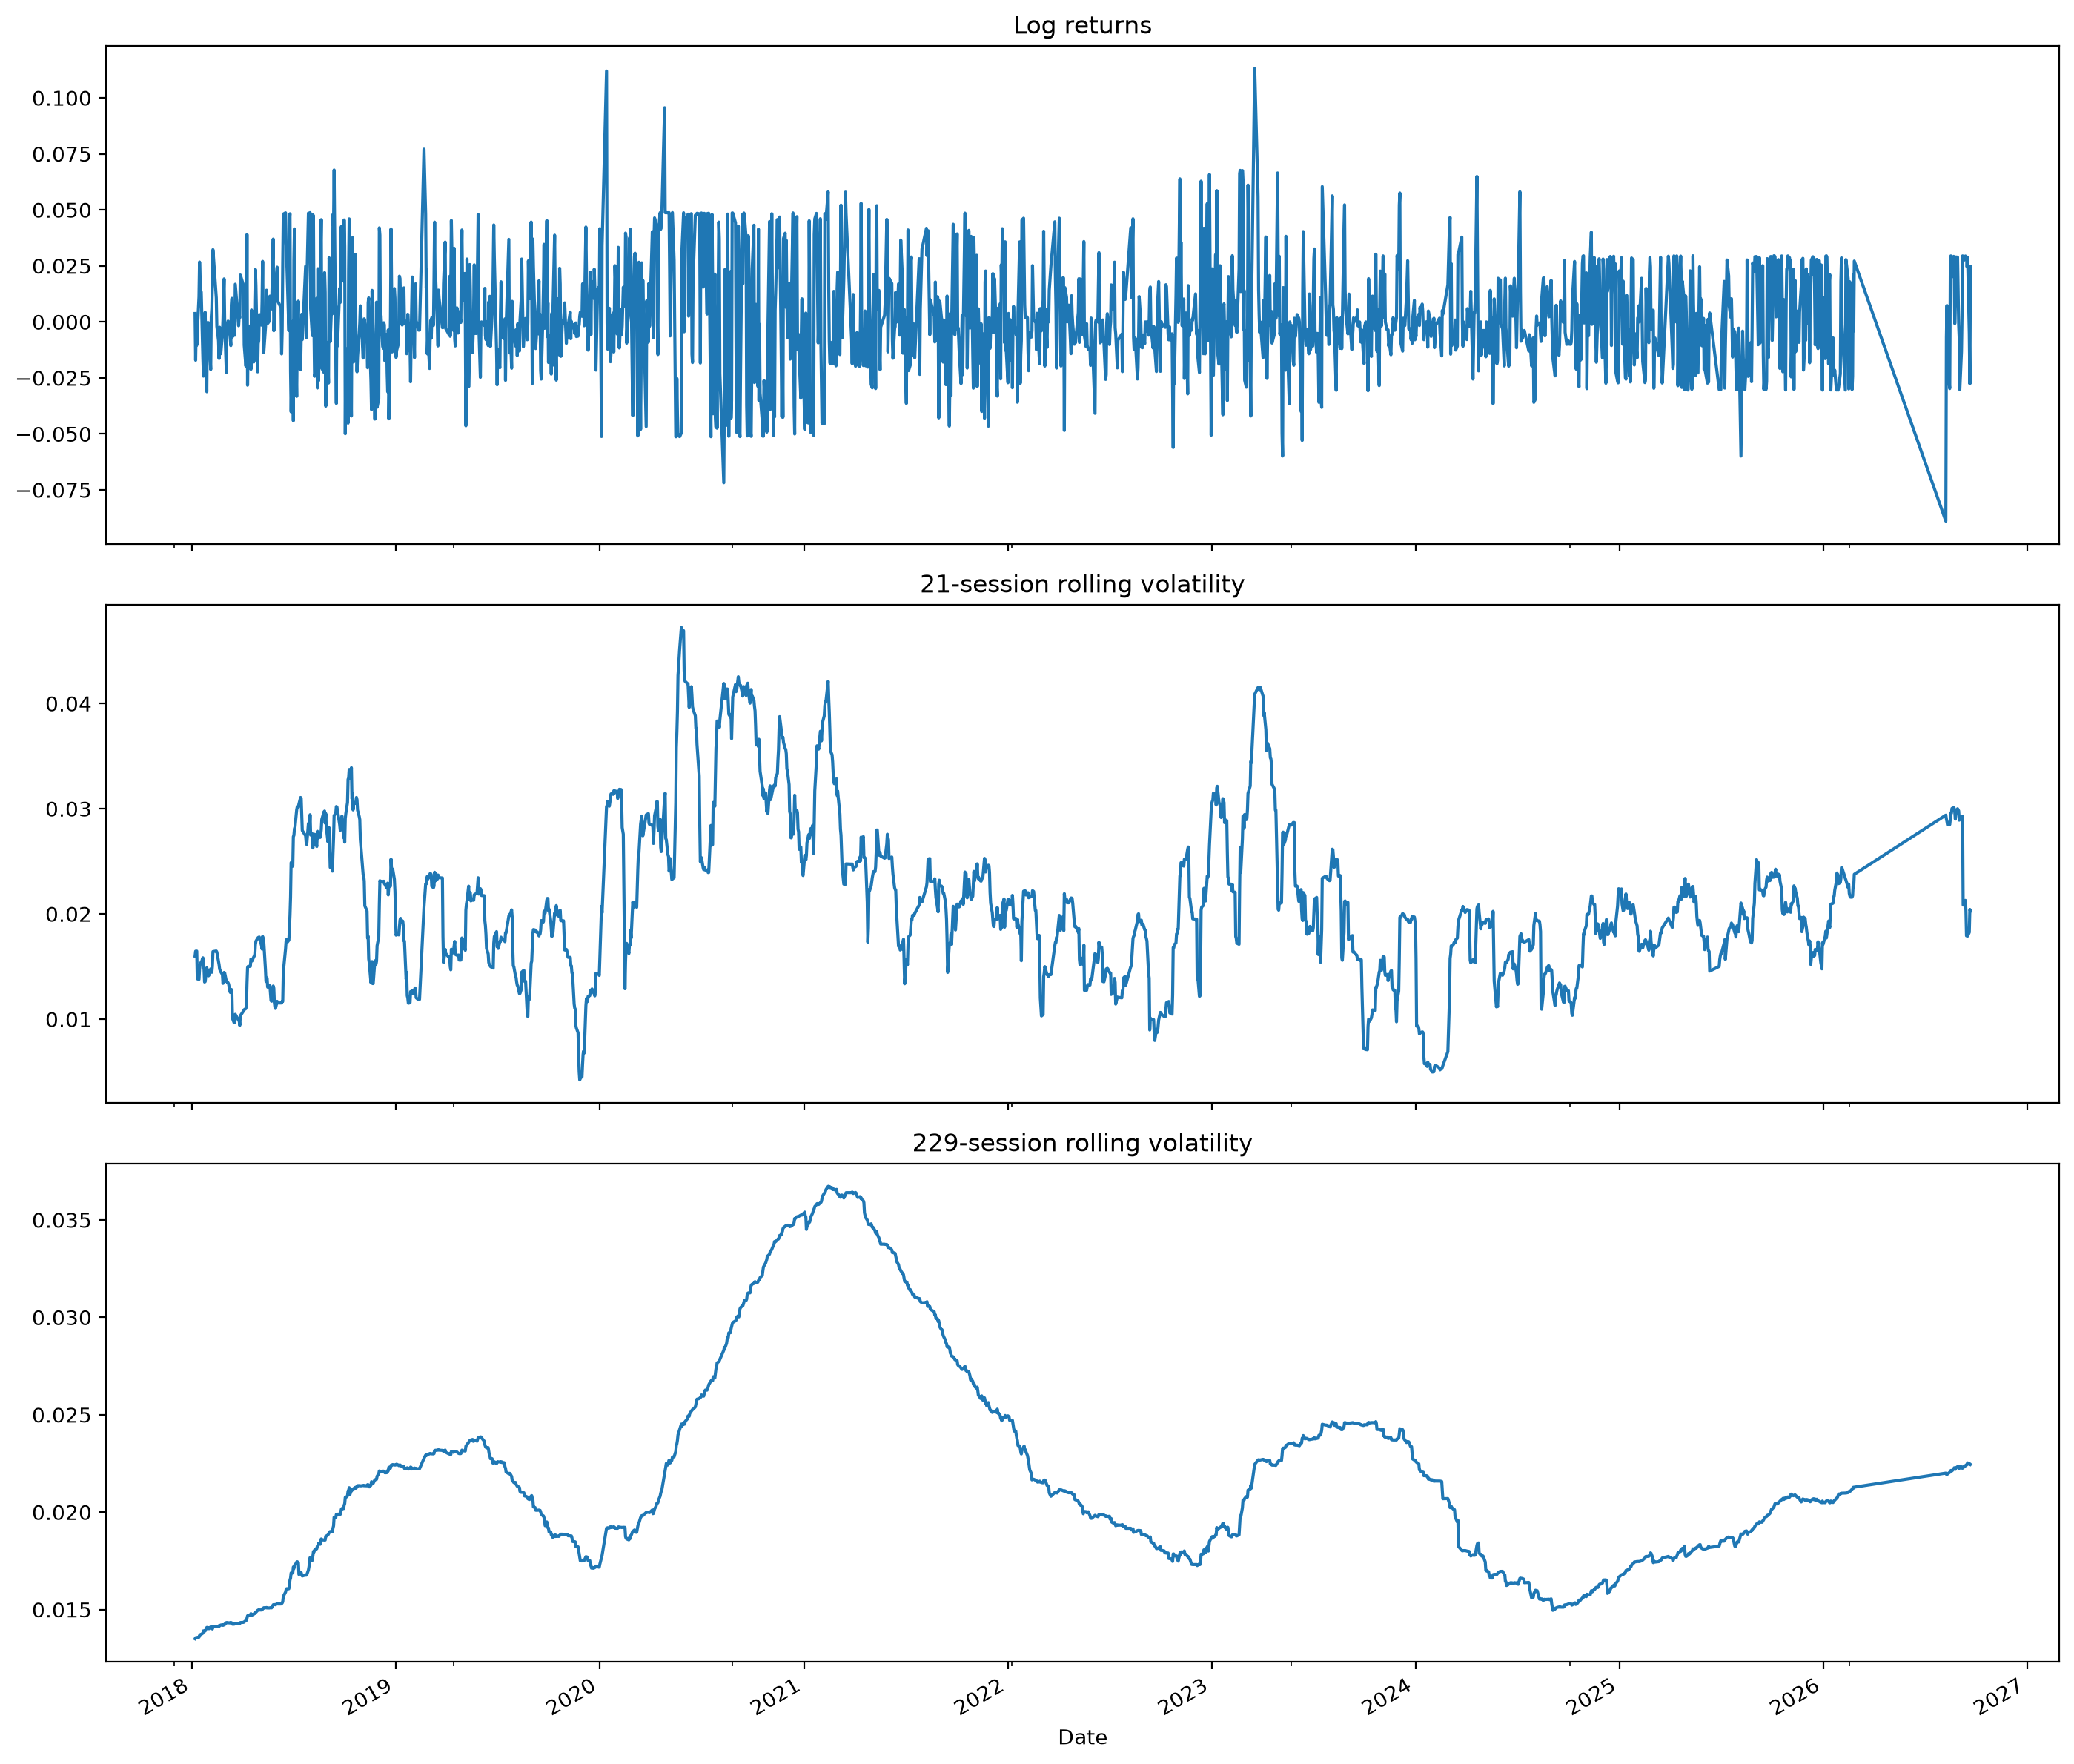

corr(return, next-day 21d vol): 0.048


In [19]:
vol = pd.DataFrame({"rtn": r, "vol_21": r.rolling(21).std(), "vol_year": r.rolling(N_DAYS).std()}).dropna()
fig, ax = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
vol["rtn"].plot(ax=ax[0], title="Log returns")
vol["vol_21"].plot(ax=ax[1], title="21-session rolling volatility")
vol["vol_year"].plot(ax=ax[2], title=f"{N_DAYS}-session rolling volatility")
plt.tight_layout()
plt.show()
print("corr(return, next-day 21d vol):", vol["rtn"].corr(vol["vol_21"].shift(-1)).round(3))

In [20]:
lev_tbl = pd.Series(
    {f"h={h}": r.corr(r.rolling(21).std().shift(-h)) for h in (1, 5, 21)},
    name="corr(return, 21-session volatility h sessions later)",
).round(3)
lev_corr = lev_tbl.iloc[0]
print(lev_tbl)

next_abs = r.abs().shift(-1)
print("mean |return| after a down session:", round(next_abs[r < 0].mean(), 4))
print("mean |return| after an up session: ", round(next_abs[r > 0].mean(), 4))

h=1     0.043
h=5     0.037
h=21    0.052
Name: corr(return, 21-session volatility h sessions later), dtype: float64
mean |return| after a down session: 0.0151
mean |return| after an up session:  0.0185


### The five facts, counted

The plots above are the book's evidence; these are the test statistics behind them, and
a verdict column decided by the numbers rather than by eye.

In [21]:
verdict = pd.DataFrame([
    ("1 non-Gaussian returns",
     f"Jarque-Bera p={jb_p:.1e}, excess kurtosis {excess_kurt:+.2f}, skew {scs.skew(r):+.2f}",
     "holds" if jb_p < 0.01 else "not shown"),
    ("2 volatility clustering",
     f"Engle ARCH(12) p={arch_p:.1e}",
     "holds" if arch_p < 0.01 else "not shown"),
    ("3 no autocorrelation in returns",
     f"Ljung-Box(20) p={lb_returns:.3f}, acf(1)={acf_raw[1]:+.3f} vs band {ci:.3f}",
     "violated" if lb_returns < 0.05 else "holds"),
    ("4 autocorrelation in |r| and r^2",
     f"acf|r|(20)={acf_abs[20]:+.3f}, acf r^2(20)={acf_sq[20]:+.3f}, band {ci:.3f}",
     "holds" if acf_abs[20] > ci else "not shown"),
    ("5 leverage effect",
     f"corr(r_t, vol_t+1)={lev_corr:+.3f}",
     "absent" if lev_corr >= 0 else "holds"),
], columns=["stylised fact", "statistic", f"on فولاد, {len(r)} sessions"])
verdict

,stylised fact,statistic,"on فولاد, 2119 sessions"
0,1 non-Gaussian returns,"Jarque-Bera p=1.9e-26, excess kurtosis +0.95, ...",holds
1,2 volatility clustering,Engle ARCH(12) p=3.9e-53,holds
2,3 no autocorrelation in returns,"Ljung-Box(20) p=0.000, acf(1)=+0.317 vs band 0...",violated
3,4 autocorrelation in |r| and r^2,"acf|r|(20)=+0.149, acf r^2(20)=+0.120, band 0.043",holds
4,5 leverage effect,"corr(r_t, vol_t+1)=+0.043",absent


### What the data says

Three of the book's five facts hold on فولاد, one is absent, and one is violated. The
violation is the interesting part.

**Fact 1 holds, weakly.** Excess kurtosis is +0.95; the S&P 500 series the book uses
sits above 10. Ten sessions exceed three sigma against 5.7 for a normal, and two exceed
five sigma, so the tails are fat, but only just. The reason is structural: TSETMC caps
each session's move (the 98th percentile of absolute returns is 5% through 2023 and
exactly 3% in 2025 and 2026), so in 2,119 sessions the largest single-session return is
12%, and every move beyond the limit is a reopening after a halt. Limits clip
the tails that give Western indices their kurtosis.

**Fact 2 holds.** Engle's ARCH test rejects constant variance at p = 4e-53; the calmest
decile of 21-session volatility is 1.16% a day, the wildest 3.05%.

**Fact 3 is violated.** Lag-1 autocorrelation of returns is +0.32 against a white-noise
band of 0.04, and Ljung-Box rejects at every lag. On a US large cap this would be a
tradable anomaly; here it is a mechanical consequence of the same price limit. A move that
wants to be 10% is spread across three or four limit-up sessions with a buy queue, so
each session predicts the next. TSETMC's `Close` is also the session's volume-weighted
average price, and averaging within the session smooths it toward the previous one.
Neither effect is a free lunch: the order book that carries the autocorrelation is the
queue you cannot get filled in.

**Fact 4 holds.** Autocorrelation of absolute returns is 0.30 at lag 1 and still 0.15 at
lag 20; the raw series is at zero by lag 20. Same shape as the book.

**Fact 5 is absent.** The correlation between a return and the next session's volatility
is +0.04, and volatility after an up session (1.85% mean absolute move) is higher than
after a down one (1.51%). That is the opposite of the leverage effect: on this market
rallies cluster harder than sell-offs, again the signature of limit-up queues.

The eleven outliers in 1.5 and the ten 3-sigma sessions above are the events worth
annotating with what happened that week (halts, capital increases, currency moves,
geopolitics); the statistics say where to look, not why.

# Chapter 2: Technical analysis

## 2.1 Candlestick chart

The book uses cufflinks/plotly. A matplotlib version keeps the notebook free of a second
plotting stack: green when the close is above the open, red otherwise, volume beneath.

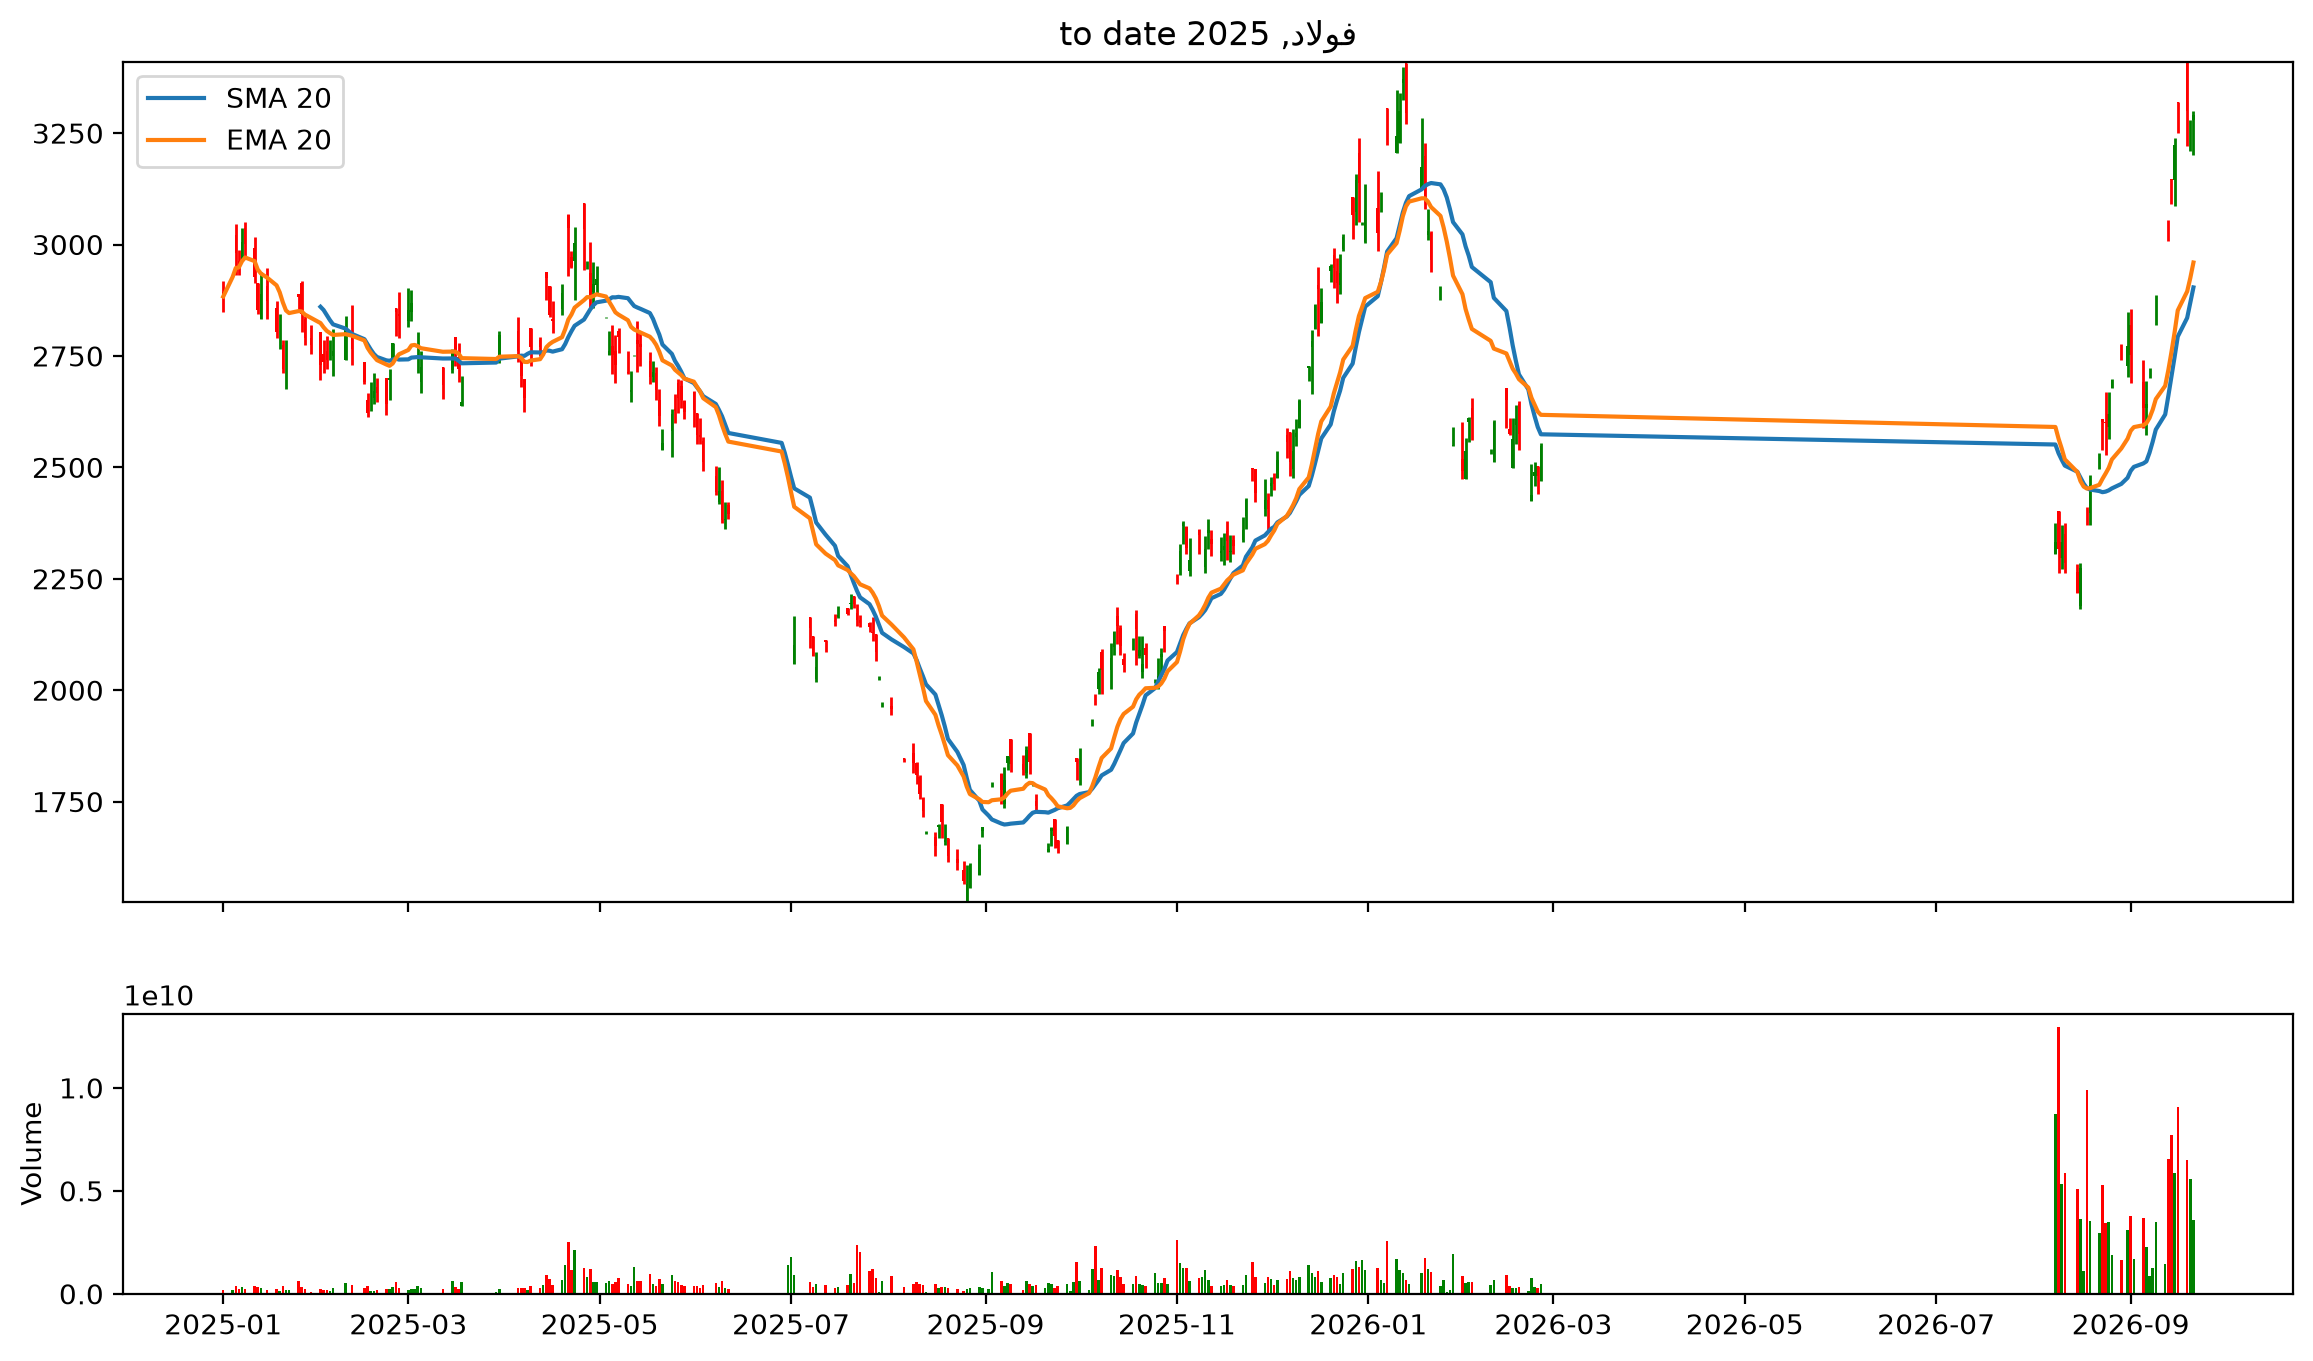

In [22]:
def candlestick(frame, title):
    fig, (ax, axv) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    up = frame["Close"] >= frame["Open"]
    colors = np.where(up, "green", "red")
    ax.vlines(frame.index, frame["Low"], frame["High"], color=colors, linewidth=1)
    ax.bar(frame.index, frame["Close"] - frame["Open"], bottom=frame["Open"], color=colors, width=0.8)
    ax.plot(frame.index, frame["Close"].rolling(20).mean(), color="tab:blue", label="SMA 20")
    ax.plot(frame.index, frame["Close"].ewm(span=20).mean(), color="tab:orange", label="EMA 20")
    ax.legend()
    ax.set_title(title)
    axv.bar(frame.index, frame["Volume"], color=colors, width=0.8)
    axv.set_ylabel("Volume")
    plt.show()

candlestick(df.loc["2025-01-01":], "فولاد, 2025 to date")

## 2.2 Backtesting a simple moving average strategy

Same `backtrader` code shape as the book: buy when the close crosses above its
20-session SMA, sell when it crosses below, all-in each time. TSETMC's `Close` is the
volume-weighted daily closing price; `Last` is the last trade. backtrader takes the
five OHLCV columns and ignores the rest.

SMA(20): 1,120,967,651 Rial | buy and hold: 14,076,818,106 Rial


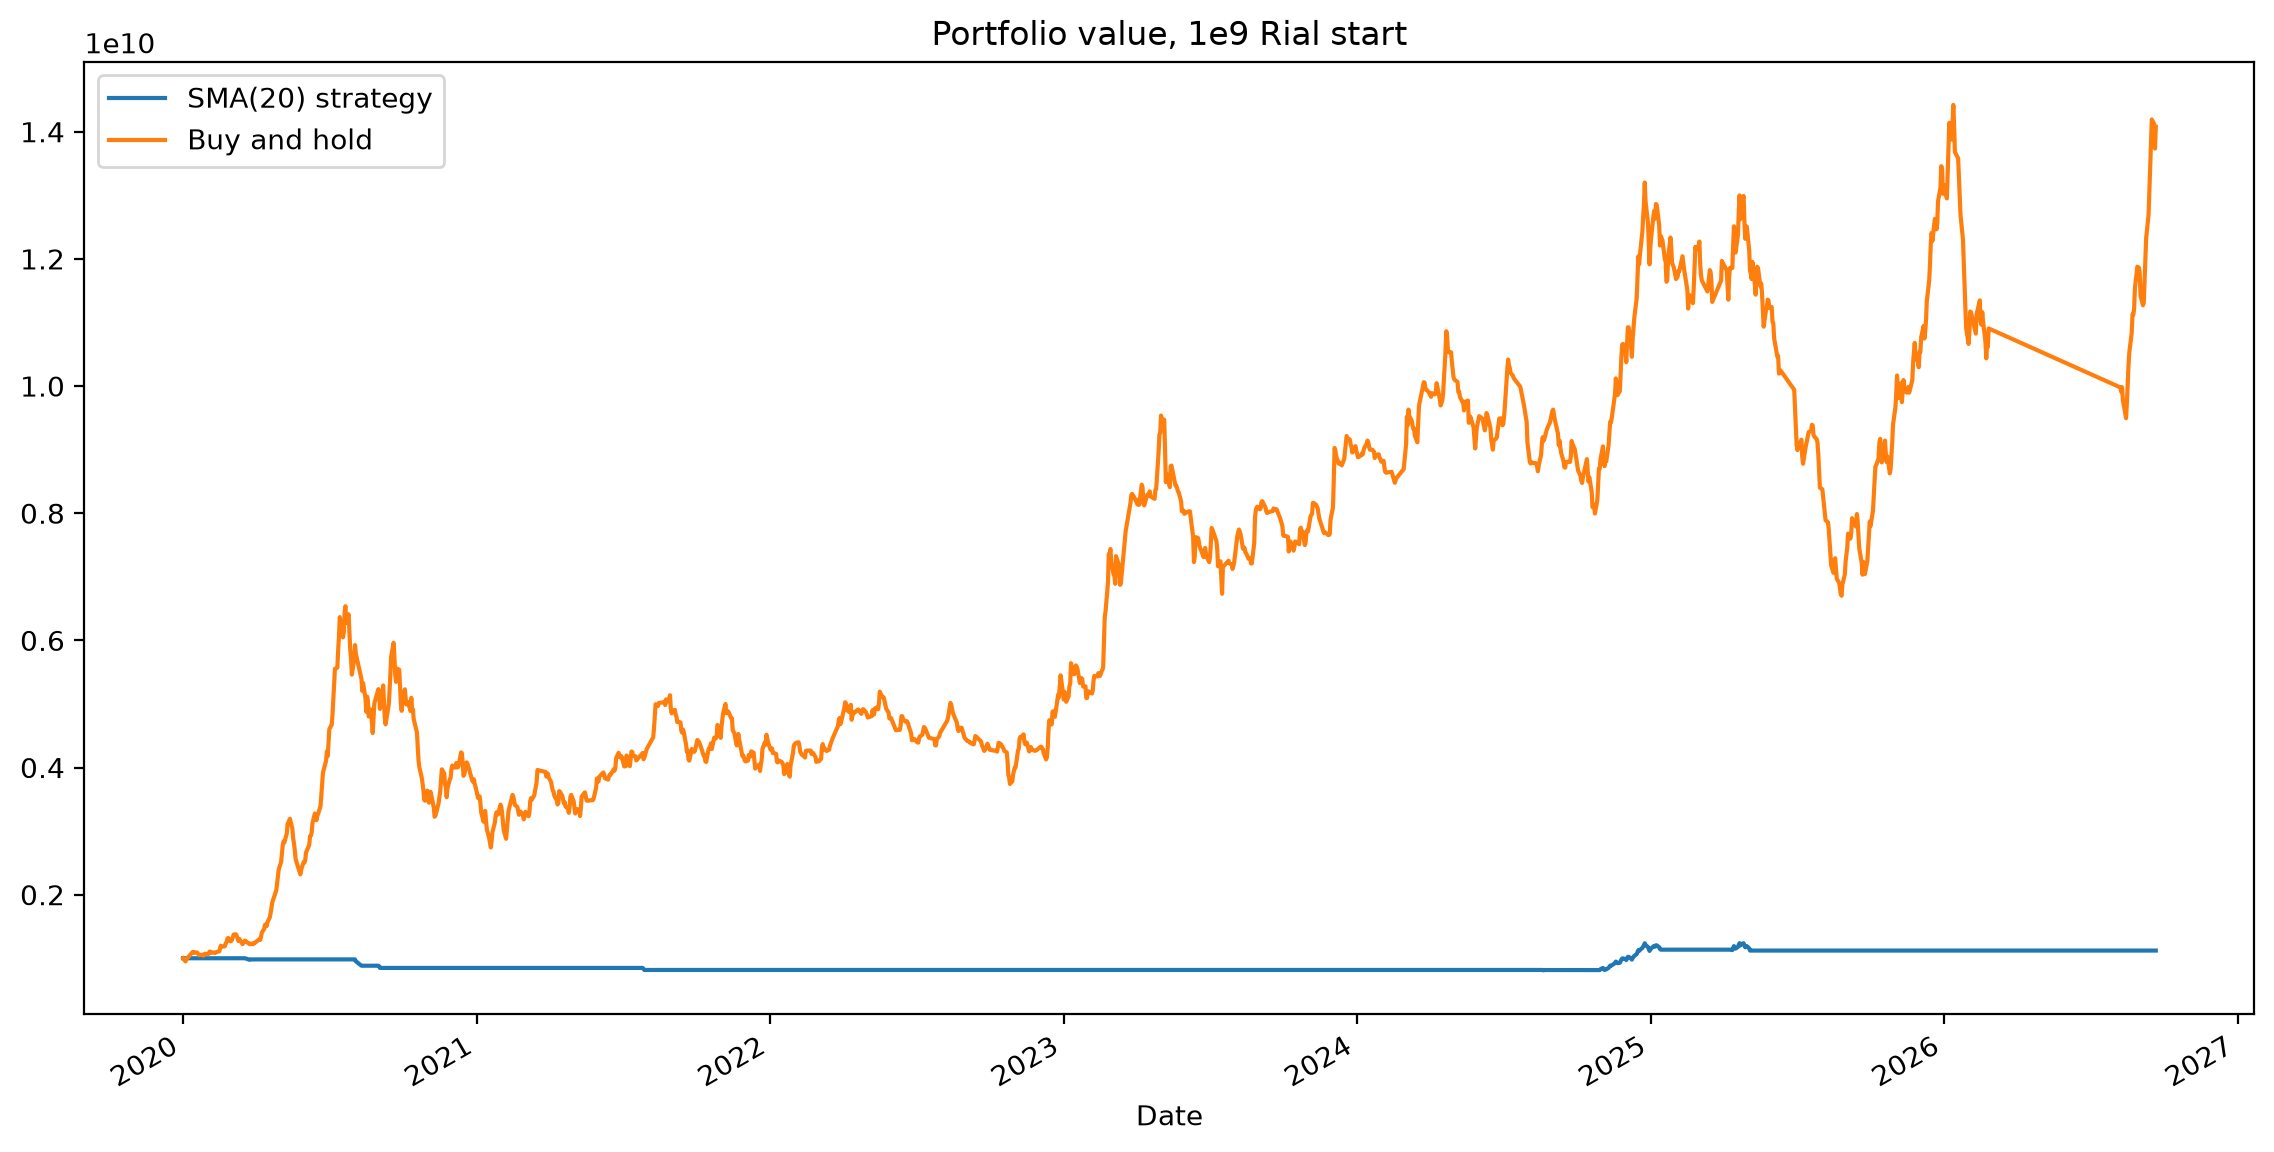

In [23]:
class SmaSignal(bt.Strategy):
    params = (("period", 20),)

    def __init__(self):
        self.signal = bt.ind.CrossOver(self.data.close, bt.ind.SMA(period=self.p.period))

    def next(self):
        if not self.position and self.signal > 0:
            size = int(self.broker.getcash() / self.data.open[0])
            self.buy(size=size)
        elif self.position and self.signal < 0:
            self.sell(size=self.position.size)


def run_backtest(strategy, frame, cash=1e9, **kwargs):
    """Returns (final_value, equity_curve, strategy) for a strategy on an OHLCV frame."""
    data = bt.feeds.PandasData(dataname=frame[["Open", "High", "Low", "Close", "Volume"]])
    cerebro = bt.Cerebro(stdstats=False)
    cerebro.adddata(data)
    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=0.0)
    cerebro.addstrategy(strategy, **kwargs)
    cerebro.addsizer(bt.sizers.PercentSizer, percents=95)
    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name="returns", timeframe=bt.TimeFrame.Days)
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="trades")
    result = cerebro.run()[0]
    daily = pd.Series(result.analyzers.returns.get_analysis())
    daily.index = pd.to_datetime(daily.index)
    equity = cash * (1 + daily).cumprod()
    return cerebro.broker.getvalue(), equity, result


bt_df = df.loc["2020-01-01":]
final, sma_equity, sma_strat = run_backtest(SmaSignal, bt_df)
buy_hold = 1e9 * bt_df["Close"] / bt_df["Close"].iloc[0]
print(f"SMA(20): {final:,.0f} Rial | buy and hold: {buy_hold.iloc[-1]:,.0f} Rial")
ax = sma_equity.plot(label="SMA(20) strategy")
buy_hold.plot(ax=ax, label="Buy and hold")
ax.set_title("Portfolio value, 1e9 Rial start")
ax.legend()
plt.show()

### There's more: the SMA period

The book optimises the period with `cerebro.optstrategy`; a loop over
`run_backtest` reads better and prints the same table.

In [24]:
grid = {p: run_backtest(SmaSignal, bt_df, period=p)[0] for p in (10, 20, 30, 50, 100)}
pd.Series(grid, name="final value").map("{:,.0f}".format)

10       951,279,706
20     1,120,967,651
30     1,335,473,396
50     1,324,119,865
100    1,125,891,118
Name: final value, dtype: str

## 2.3 Bollinger Bands and a buy/sell strategy

Buy when the close crosses the lower band upward, sell when it crosses the upper band
downward. 20 sessions, 2 standard deviations, as in the book.

Bollinger(20, 2): 1,447,517,615 Rial


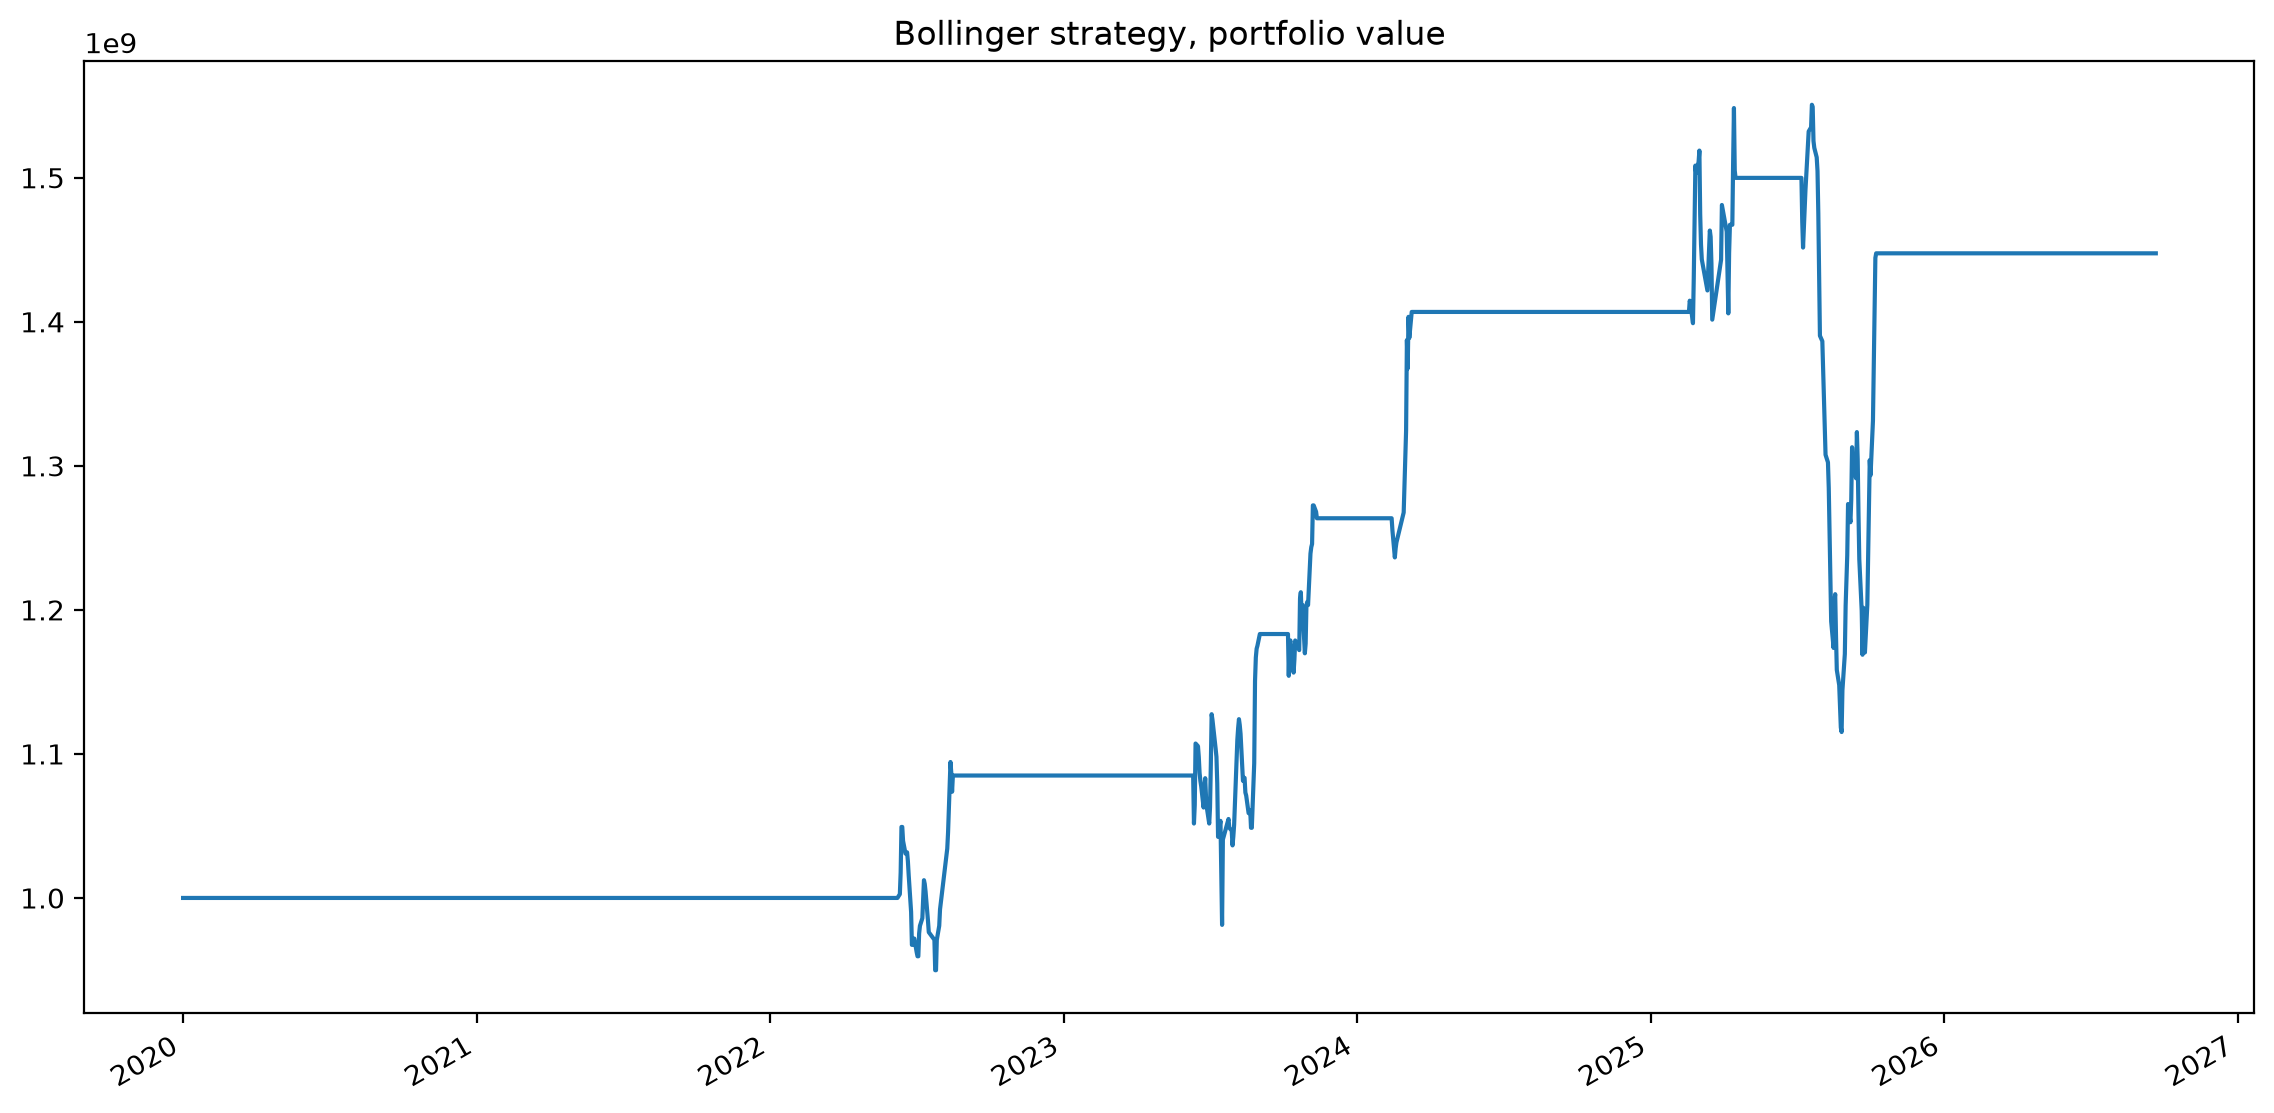

In [25]:
class BollingerSignal(bt.Strategy):
    params = (("period", 20), ("devfactor", 2.0))

    def __init__(self):
        bb = bt.ind.BollingerBands(period=self.p.period, devfactor=self.p.devfactor)
        self.buy_signal = bt.ind.CrossOver(self.data.close, bb.lines.bot)
        self.sell_signal = bt.ind.CrossOver(self.data.close, bb.lines.top)

    def next(self):
        if not self.position and self.buy_signal > 0:
            self.buy(size=int(self.broker.getcash() / self.data.open[0]))
        elif self.position and self.sell_signal < 0:
            self.sell(size=self.position.size)


final, bb_equity, bb_strat = run_backtest(BollingerSignal, bt_df)
print(f"Bollinger(20, 2): {final:,.0f} Rial")
bb_equity.plot(title="Bollinger strategy, portfolio value")
plt.show()

## 2.4 RSI and a long/short strategy

Long when the 14-session RSI crosses above 30, exit above 50; short when it crosses
below 70, exit below 50. `SignalStrategy` leaves position sizing to the sizer, which is
95% of equity per trade here; the book's default stake of one share would buy a single
30,000-Rial share against a billion in cash and draw a flat line. TSETMC has no short
selling, so the short leg is paper-only, exactly as the book's US example ignores
borrow costs.

RSI(14): 250,421,370 Rial


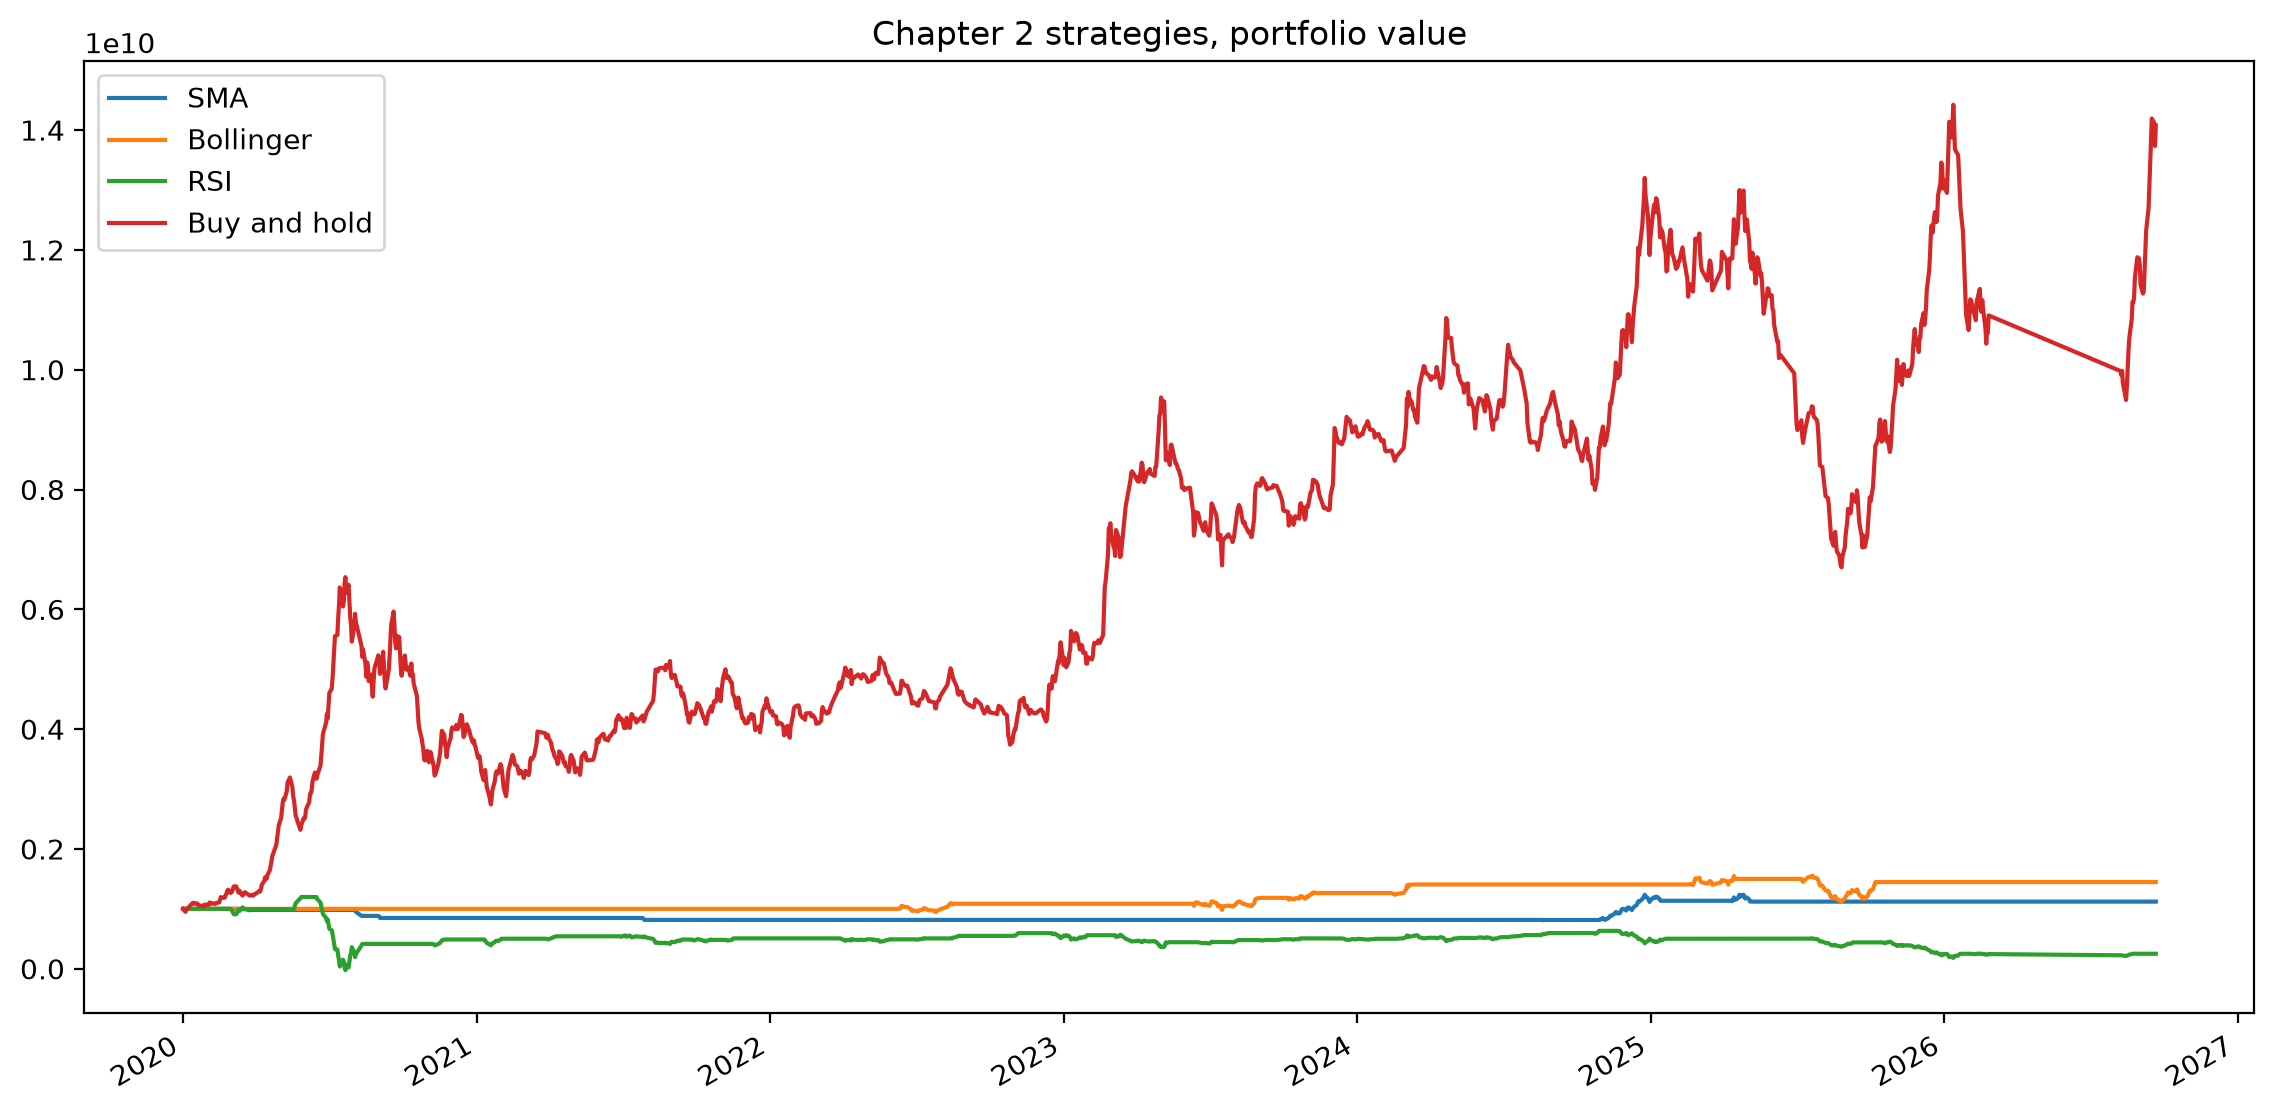

In [26]:
class RsiSignal(bt.SignalStrategy):
    params = dict(rsi_periods=14, rsi_upper=70, rsi_lower=30, rsi_mid=50)

    def __init__(self):
        rsi = bt.ind.RSI(period=self.p.rsi_periods, upperband=self.p.rsi_upper, lowerband=self.p.rsi_lower)
        self.signal_add(bt.SIGNAL_LONG, bt.ind.CrossUp(rsi, self.p.rsi_lower, plot=False))
        self.signal_add(bt.SIGNAL_LONGEXIT, -(rsi > self.p.rsi_mid))
        self.signal_add(bt.SIGNAL_SHORT, -bt.ind.CrossDown(rsi, self.p.rsi_upper, plot=False))
        self.signal_add(bt.SIGNAL_SHORTEXIT, rsi < self.p.rsi_mid)


final, rsi_equity, rsi_strat = run_backtest(RsiSignal, bt_df)
print(f"RSI(14): {final:,.0f} Rial")
curves = {"SMA": sma_equity, "Bollinger": bb_equity, "RSI": rsi_equity, "Buy and hold": buy_hold}
ax = pd.DataFrame(curves).plot()
ax.set_title("Chapter 2 strategies, portfolio value")
plt.show()

### Reading the backtests

The three strategies against buy and hold on the same window: compound growth,
annualised volatility, worst drawdown, closed trades and win rate. Commission is zero
and TSETMC's price limits and order queues are not modelled, so every number here
flatters the strategies rather than the benchmark.

In [27]:
def strategy_stats(name, equity, strat=None):
    daily = equity.pct_change().dropna()
    years = len(equity) / N_DAYS
    stats = {
        "final (Rial)": equity.iloc[-1],
        "CAGR": (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1,
        "annual vol": daily.std() * np.sqrt(N_DAYS),
        "max drawdown": (equity / equity.cummax() - 1).min(),
        "sessions with P&L": (daily != 0).mean(),
    }
    if strat is not None:
        ta = strat.analyzers.trades.get_analysis()
        closed = ta.get("total", {}).get("closed", 0)
        stats["trades"] = closed
        stats["win rate"] = ta.get("won", {}).get("total", 0) / closed if closed else np.nan
    else:
        stats["trades"], stats["win rate"] = 1, np.nan
    return pd.Series(stats, name=name)


bt_stats = pd.DataFrame([
    strategy_stats("SMA(20)", sma_equity, sma_strat),
    strategy_stats("Bollinger(20, 2)", bb_equity, bb_strat),
    strategy_stats("RSI(14)", rsi_equity, rsi_strat),
    strategy_stats("Buy and hold", buy_hold),
])
shown = bt_stats.copy()
for col in ("CAGR", "annual vol", "max drawdown", "sessions with P&L", "win rate"):
    shown[col] = bt_stats[col].map(lambda v: "-" if pd.isna(v) else f"{v:.1%}")
shown["final (Rial)"] = bt_stats["final (Rial)"].map("{:,.0f}".format)
shown

,final (Rial),CAGR,annual vol,max drawdown,sessions with P&L,trades,win rate
SMA(20),"1,120,967,651",1.9%,8.1%,-19.0%,5.6%,7.0,14.3%
"Bollinger(20, 2)","1,447,517,615",6.1%,11.6%,-28.1%,14.5%,6.0,83.3%
RSI(14),"250,421,370",-19.9%,303.3%,-102.0%,41.2%,30.0,60.0%
Buy and hold,"14,076,818,106",53.0%,36.6%,-58.1%,96.2%,1.0,-


### What the data says

Every strategy loses to buy and hold by an order of magnitude: 14.1 billion Rial against
1.1, 1.4 and 0.25 billion, or a 53% CAGR against 2%, 6% and -20%.

The benchmark is not a fair fight. Most of فولاد's 14x in Rial over this window is currency
debasement rather than steel; the README's example prices the same stock in dollars and it
is down. Trend rules that sit in cash for 85% (Bollinger) to 94% (SMA) of sessions forfeit
that drift on every flat day, and on TSETMC the drift is the whole return.

The rest is market structure. Crossover signals fire in the middle of a limit-up queue
(the +0.32 autocorrelation of chapter 1), and backtrader fills the next open as if the
queue did not exist. The win rates show which mechanism each rule is trading: Bollinger's
mean reversion wins 5 of 6 trades and makes 6% a year; the SMA wins 1 of 7 and lives on
that one; RSI trades 30 times at a 60% hit rate and still ends down 75% because the short
leg fights a stock that only goes up. Its drawdown reads -102%: the account went below
zero, which is a margin call anywhere and impossible on an exchange with no short selling.
Commission is zero throughout; brokerage and exchange fees on both legs would take a
further slice from the SMA's 1.9% and Bollinger's 6.1%.

The period grid does not rescue the SMA. Every period from 10 to 100 lands between 0.95
and 1.34 billion; the choice of lookback moves the result by a third, the choice of
strategy against buy and hold by a factor of ten.

# Chapter 7: Asset allocation

## 7.1 A basic 1/n portfolio

Four TSETMC stocks and two Nobitex pairs. `download()` returns the book's
`(Price, Ticker)` column layout and takes both kinds in one call.

The book then calls `dropna()`, which on liquid US names keeps every trading day. It
cannot be used here. TSETMC symbols halt independently, sometimes for months (فولاد was
suspended for 164 calendar days in 2026), so the six-way intersection keeps only the
days on which all six happened to trade and turns a multi-month move into one "daily"
return: on the intersected frame شپنا shows a +143% session, which never happened in a
market with a 3% daily limit.

The frame below is built on the TSETMC session calendar instead, defined as any day at
least one of the four stocks traded, restricted to the range Nobitex covers. A halted
stock keeps its last price, so it returns zero while suspended and its reopening move
lands on one session. Returns are unit-free, so the Toman crypto columns need no
rescaling. pyfolio does not run on current pandas, so the four headline metrics are
computed by hand.

(269, 6) 2025-05-10 -> 2026-09-21
book's dropna() would keep: 197 rows

largest single-session move, and share of sessions with no price change:
         max |move| stale sessions
Ticker                            
فولاد         0.085          20.9%
فملی          0.037           6.3%
شپنا          0.096           2.2%
وبملت         0.130           5.2%
BTC-IRT       0.225           0.4%
ETH-IRT       0.174           1.1%

annual return        142.84%
annual volatility     24.13%
sharpe (rf=0)        592.07%
max drawdown         -24.59%
dtype: str


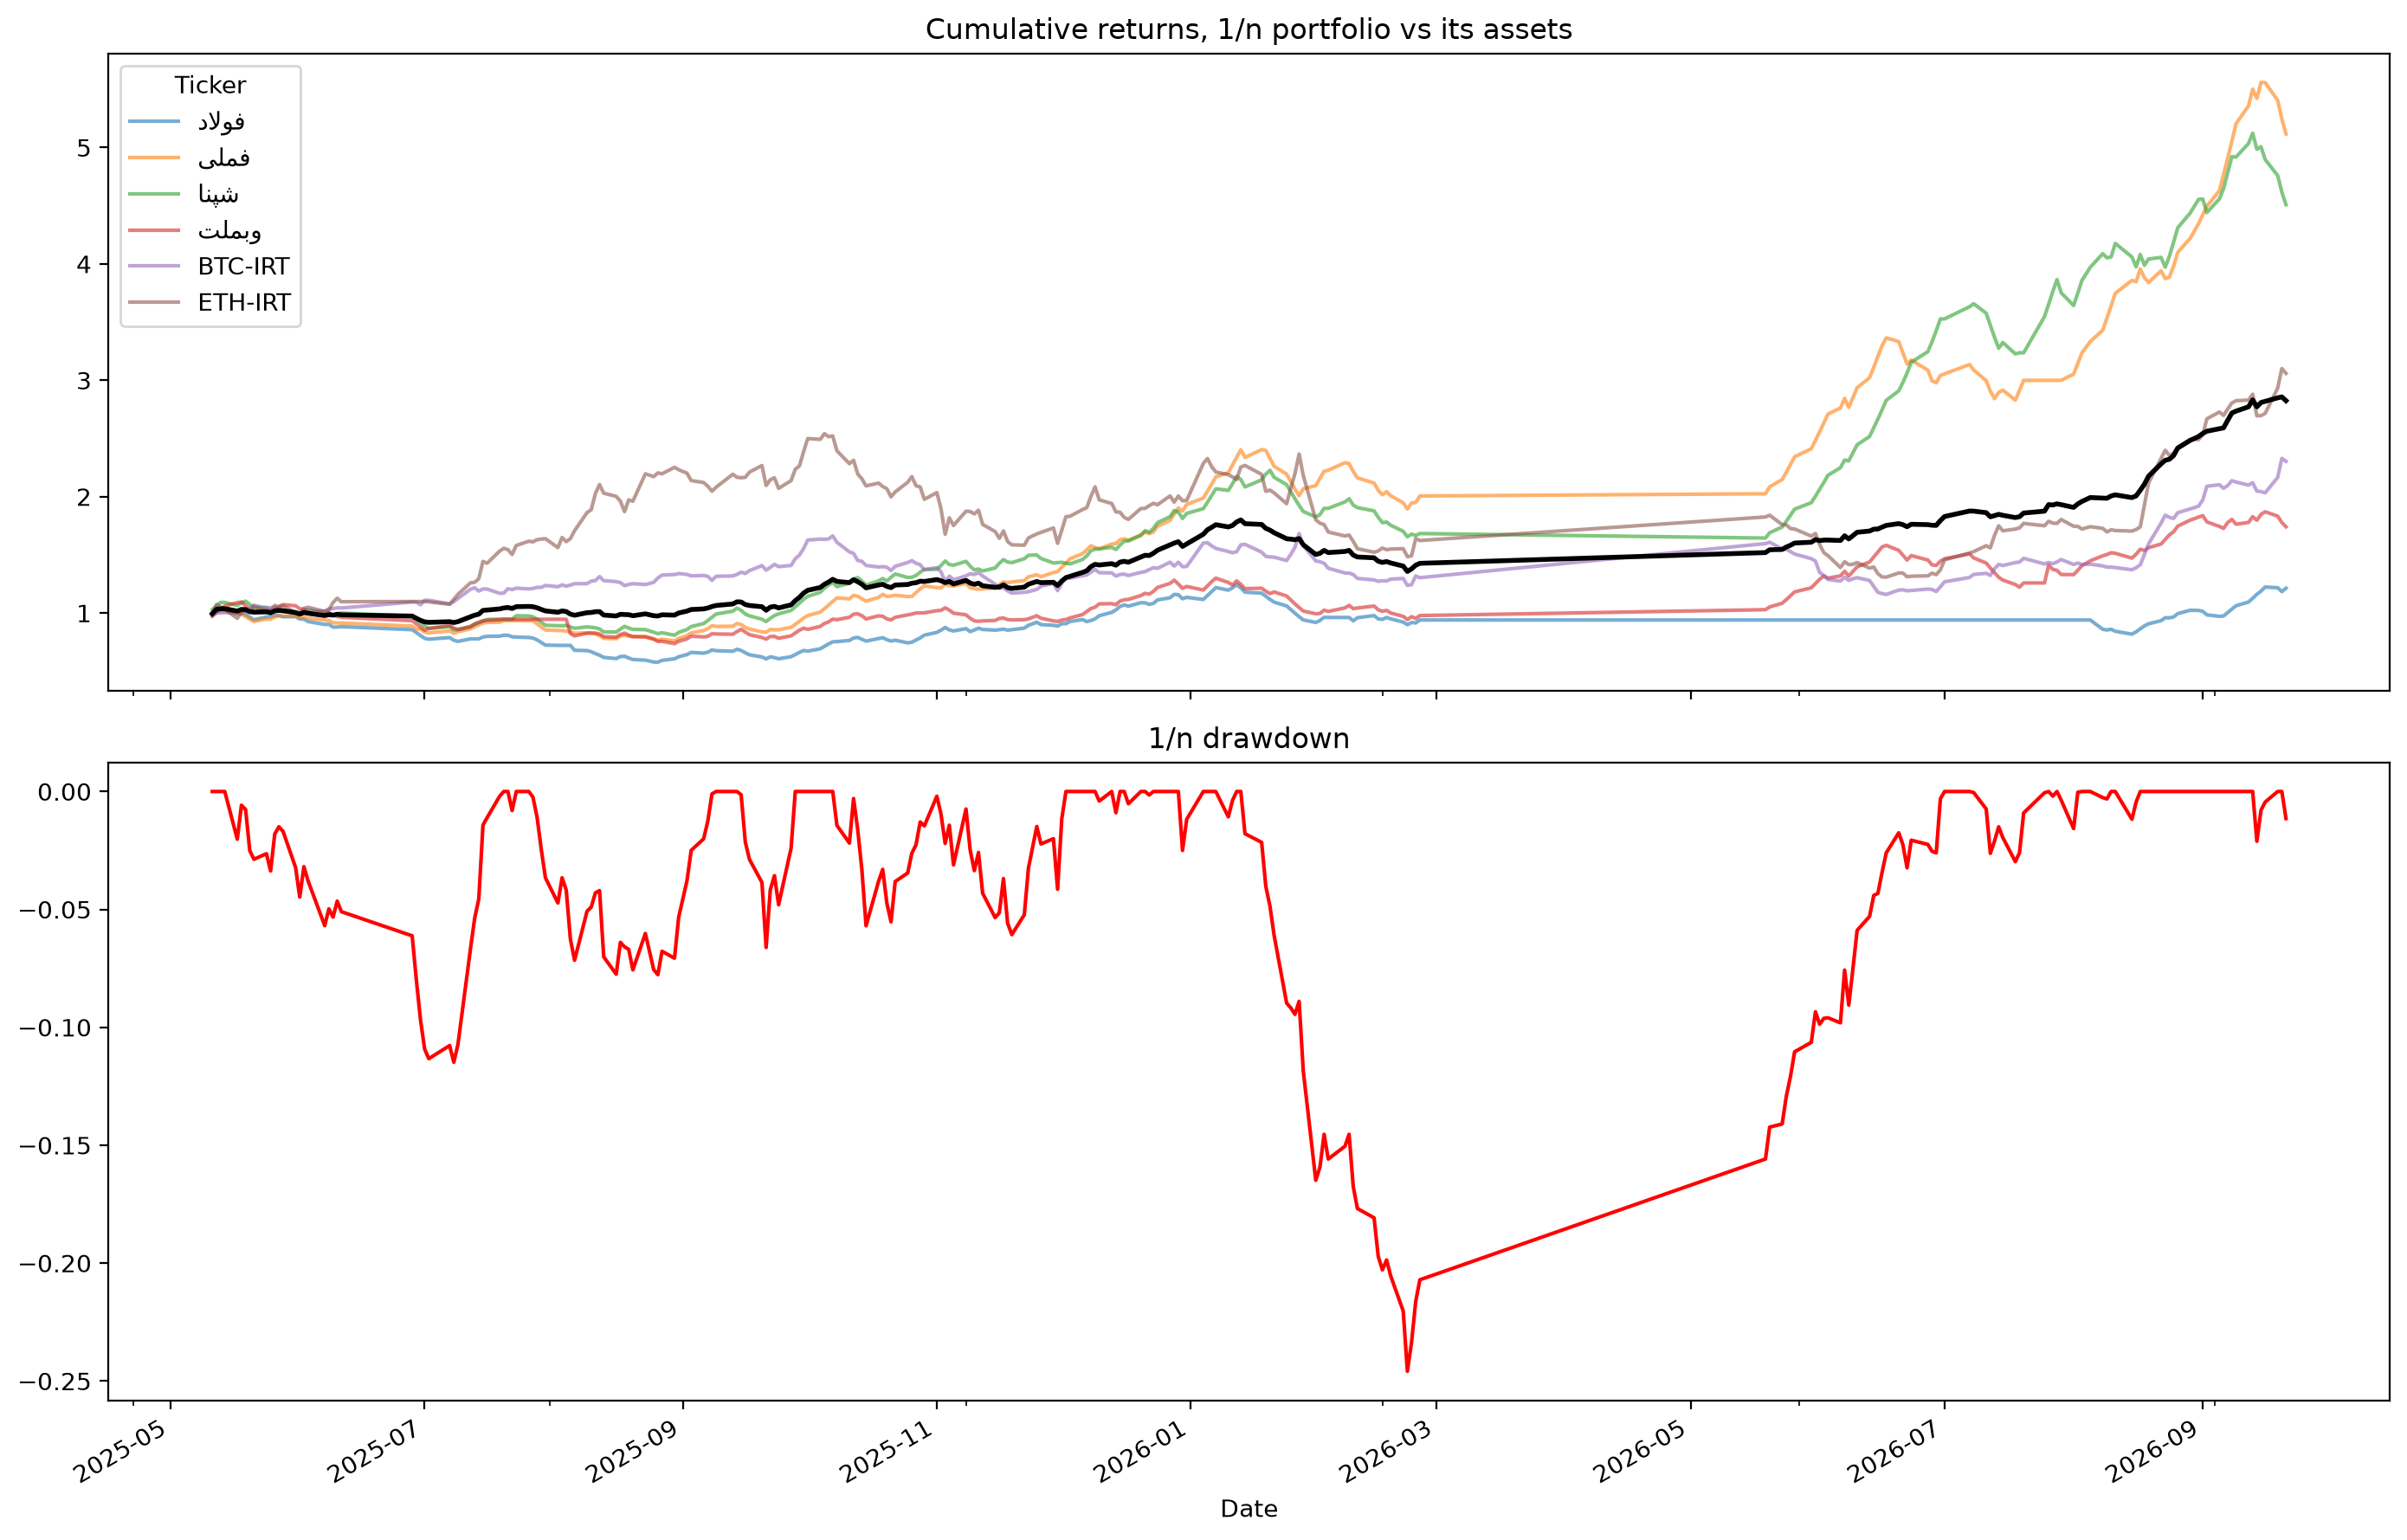

In [28]:
RISKY_ASSETS = ["فولاد", "فملی", "شپنا", "وبملت", "BTC-IRT", "ETH-IRT"]
equities, cryptos = RISKY_ASSETS[:4], RISKY_ASSETS[4:]
raw = yf.download(RISKY_ASSETS, start="2020-01-01", progress=False)["Close"]

sessions_idx = raw.index[raw[equities].notna().any(axis=1)]
sessions_idx = sessions_idx[sessions_idx >= raw[cryptos].dropna().index.min()]
prices = raw.ffill().reindex(sessions_idx).dropna()
print(prices.shape, prices.index.min().date(), "->", prices.index.max().date())
print("book's dropna() would keep:", len(raw.dropna()), "rows")

returns = prices.pct_change().dropna()
print("\nlargest single-session move, and share of sessions with no price change:")
print(pd.DataFrame({"max |move|": returns.abs().max().round(3),
                    "stale sessions": (returns == 0).mean().map("{:.1%}".format)}))

n_assets = len(RISKY_ASSETS)
weights = np.full(n_assets, 1 / n_assets)
portfolio = pd.Series(returns.values @ weights, index=returns.index, name="1/n")


def performance(daily, n_days=N_DAYS):
    cum = (1 + daily).cumprod()
    years = len(daily) / n_days
    annual = cum.iloc[-1] ** (1 / years) - 1
    vol = daily.std() * np.sqrt(n_days)
    drawdown = (cum / cum.cummax() - 1).min()
    return pd.Series(
        {
            "annual return": annual,
            "annual volatility": vol,
            "sharpe (rf=0)": annual / vol,
            "max drawdown": drawdown,
        }
    )


print()
print(performance(portfolio).map("{:.2%}".format))
fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
(1 + returns).cumprod().plot(ax=ax[0], alpha=0.6)
(1 + portfolio).cumprod().plot(ax=ax[0], color="black", linewidth=2)
ax[0].set_title("Cumulative returns, 1/n portfolio vs its assets")
cum = (1 + portfolio).cumprod()
(cum / cum.cummax() - 1).plot(ax=ax[1], color="red", title="1/n drawdown")
plt.tight_layout()
plt.show()

## 7.2 Efficient frontier by Monte Carlo

100,000 random long-only weight vectors over the six assets, annualised with the
measured session count, Sharpe with a zero risk-free rate (Iran publishes no daily
risk-free series). The equities sit in a tight cluster on the left, the two crypto pairs
far to the right; the max-Sharpe weights show how much of that volatility the frontier
is willing to buy for the return that comes with it.

max Sharpe weights: {'فولاد': 0.006, 'فملی': 0.426, 'شپنا': 0.278, 'وبملت': 0.005, 'BTC-IRT': 0.216, 'ETH-IRT': 0.069}
min vol weights:    {'فولاد': 0.321, 'فملی': 0.222, 'شپنا': 0.195, 'وبملت': 0.002, 'BTC-IRT': 0.257, 'ETH-IRT': 0.003}


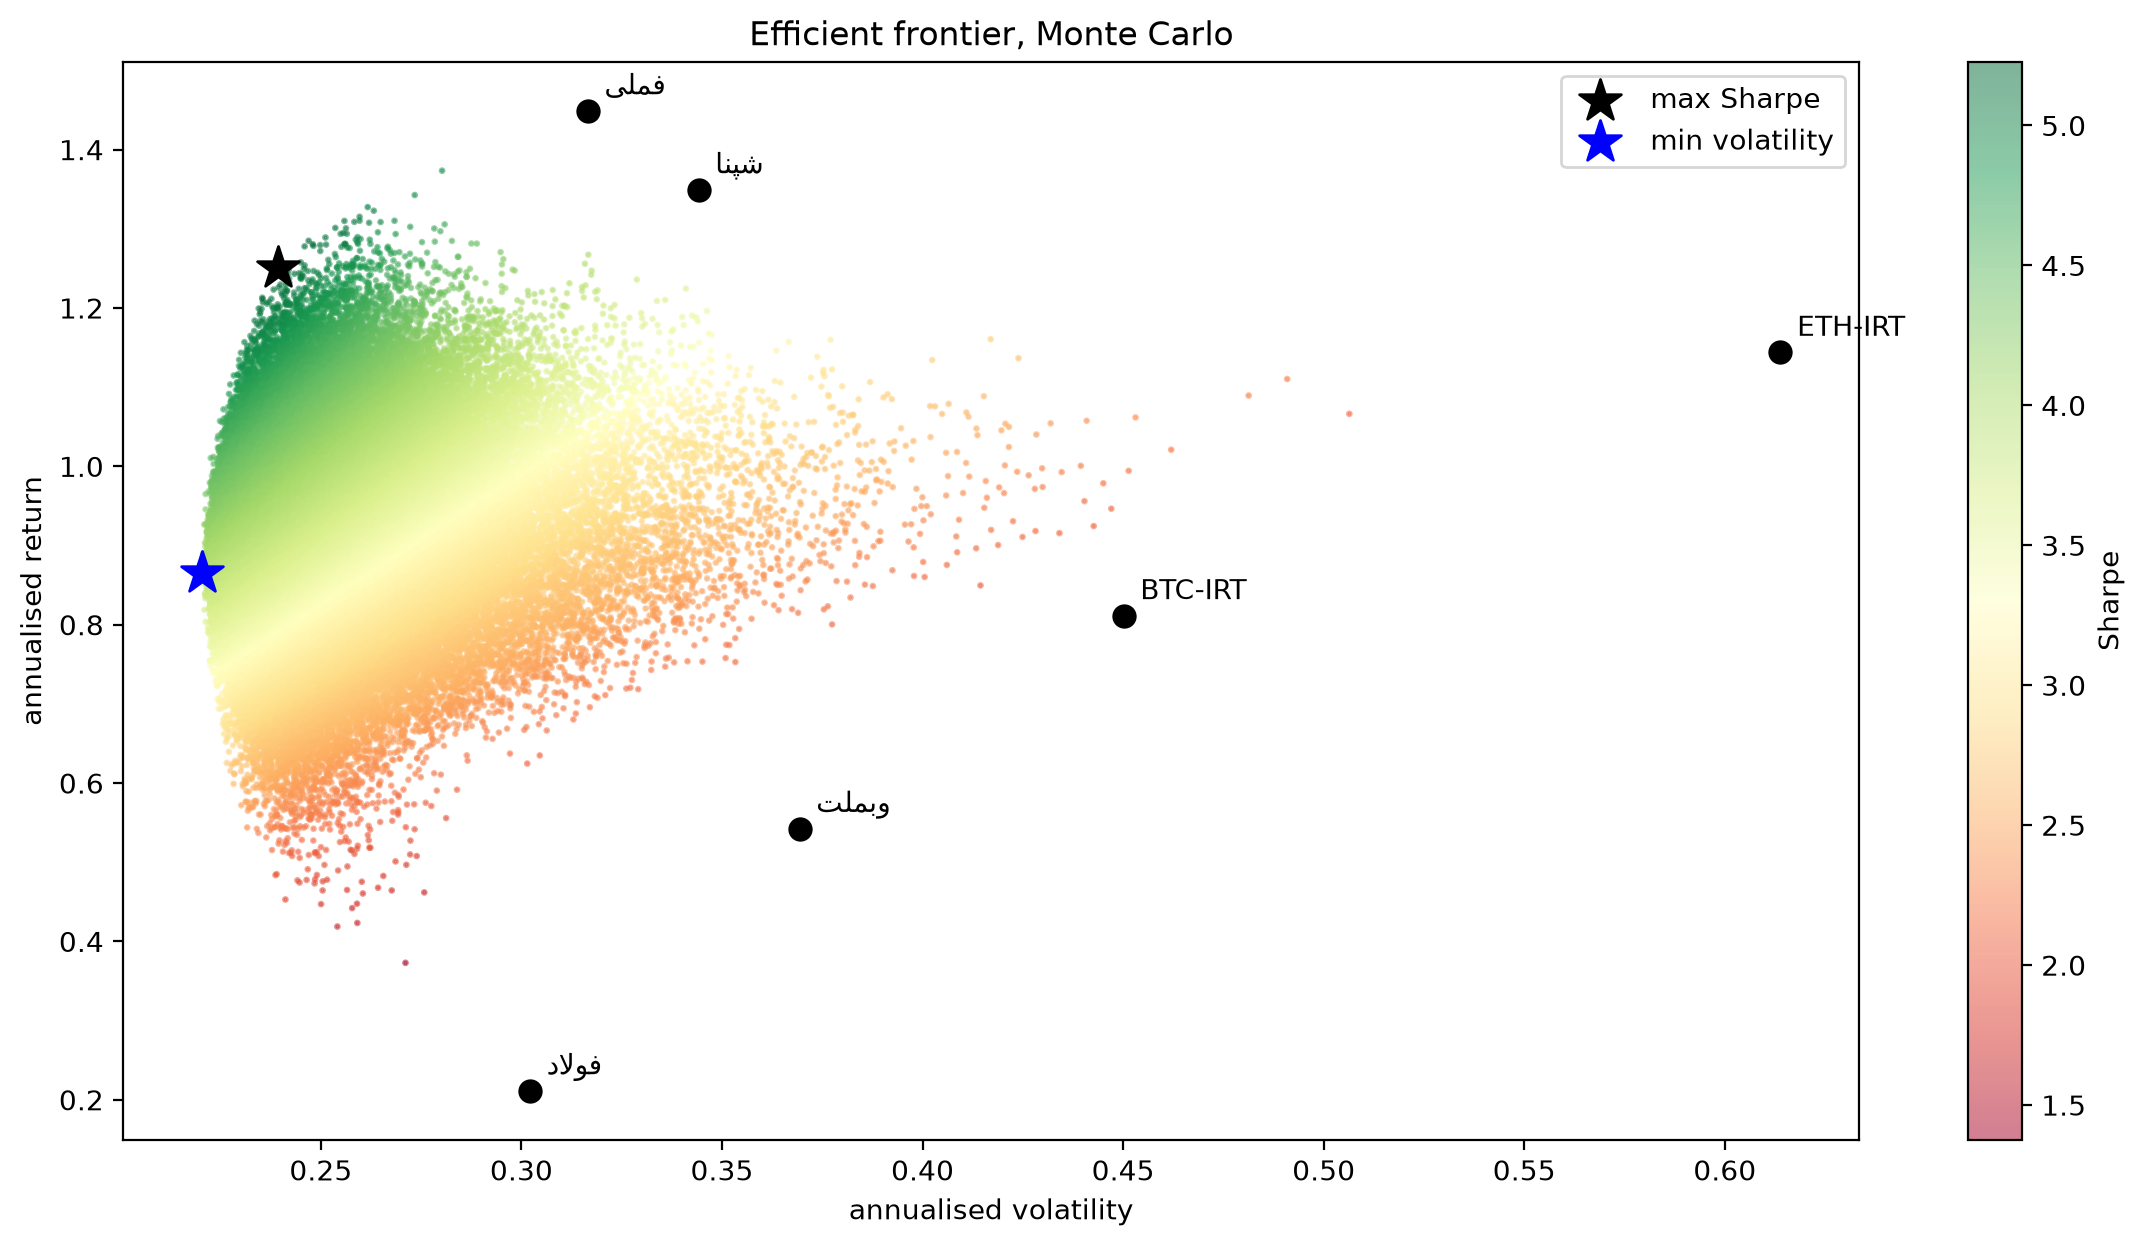

In [29]:
N_PORTFOLIOS = 10 ** 5
avg_returns = returns.mean() * N_DAYS
cov_mat = returns.cov() * N_DAYS

rng = np.random.default_rng(42)
w = rng.random((N_PORTFOLIOS, n_assets))
w /= w.sum(axis=1, keepdims=True)
p_rtn = w @ avg_returns.values
p_vol = np.sqrt(np.einsum("ij,jk,ik->i", w, cov_mat.values, w))
p_sharpe = p_rtn / p_vol
results = pd.DataFrame({"returns": p_rtn, "volatility": p_vol, "sharpe": p_sharpe})

max_sharpe = results.iloc[results["sharpe"].idxmax()]
min_vol = results.iloc[results["volatility"].idxmin()]
print("max Sharpe weights:", dict(zip(RISKY_ASSETS, w[results["sharpe"].idxmax()].round(3).tolist())))
print("min vol weights:   ", dict(zip(RISKY_ASSETS, w[results["volatility"].idxmin()].round(3).tolist())))

fig, ax = plt.subplots()
sc = ax.scatter(results["volatility"], results["returns"], c=results["sharpe"], cmap="RdYlGn", s=2, alpha=0.5)
ax.scatter(max_sharpe["volatility"], max_sharpe["returns"], marker="*",
           color="black", s=250, label="max Sharpe")
ax.scatter(min_vol["volatility"], min_vol["returns"], marker="*", color="blue", s=250, label="min volatility")
for i, asset in enumerate(RISKY_ASSETS):
    ax.scatter(np.sqrt(cov_mat.iloc[i, i]), avg_returns.iloc[i], marker="o", color="black", s=60)
    ax.annotate(asset, (np.sqrt(cov_mat.iloc[i, i]), avg_returns.iloc[i]),
                xytext=(6, 6), textcoords="offset points")
fig.colorbar(sc, label="Sharpe")
ax.set(xlabel="annualised volatility", ylabel="annualised return", title="Efficient frontier, Monte Carlo")
ax.legend()
plt.show()

### Reading the allocation

Correlations, the diversification gain of the 1/n rule, the two baskets on their own,
and what the max-Sharpe weights would have returned had they been known in advance.
That last column is in-sample: the weights were chosen on the same 269 sessions they
are scored on, so it is an upper bound, not a forecast.

In [30]:
print(returns.corr().round(2), "\n")

port_vol = portfolio.std() * np.sqrt(N_DAYS)
mean_vol = (returns.std() * np.sqrt(N_DAYS)).mean()
print(f"1/n volatility {port_vol:.1%} vs mean single-asset volatility {mean_vol:.1%}"
      f" -> diversification ratio {mean_vol / port_vol:.2f}")

equity_basket = returns[equities].mean(axis=1)
crypto_basket = returns[cryptos].mean(axis=1)
print("corr(equity basket, crypto basket):", round(equity_basket.corr(crypto_basket), 3))

best_w = w[results["sharpe"].idxmax()]
in_sample_best = pd.Series(returns.values @ best_w, index=returns.index)
table = pd.DataFrame({
    "1/n": performance(portfolio),
    "4 equities": performance(equity_basket),
    "2 cryptos": performance(crypto_basket),
    "max Sharpe (in sample)": performance(in_sample_best),
})
print()
print(table.map("{:.1%}".format))

Ticker   فولاد  فملی  شپنا  وبملت  BTC-IRT  ETH-IRT
Ticker                                             
فولاد     1.00  0.51  0.48   0.51    -0.01     0.02
فملی      0.51  1.00  0.64   0.58    -0.08    -0.03
شپنا      0.48  0.64  1.00   0.57    -0.14    -0.04
وبملت     0.51  0.58  0.57   1.00    -0.01    -0.00
BTC-IRT  -0.01 -0.08 -0.14  -0.01     1.00     0.77
ETH-IRT   0.02 -0.03 -0.04  -0.00     0.77     1.00 

1/n volatility 24.1% vs mean single-asset volatility 39.9% -> diversification ratio 1.66
corr(equity basket, crypto basket): -0.043

                      1/n 4 equities 2 cryptos max Sharpe (in sample)
annual return      142.8%     133.9%    134.6%                 238.3%
annual volatility   24.1%      27.2%     50.2%                  23.9%
sharpe (rf=0)      592.1%     492.8%    268.1%                 996.3%
max drawdown       -24.6%     -30.5%    -39.4%                 -22.3%


### What the data says

Over the 269 sessions Nobitex covers (May 2025 to September 2026) the 1/n portfolio
compounds at 143% a year with 24% volatility and a 25% maximum drawdown. Read the return
as one regime of Rial devaluation, not an expectation.

The diversification is real. The crypto basket's correlation with the equity basket is
-0.04: the pairs are priced off BTC/USD and the free-market dollar, neither of which
tracks TSETMC. The four equities correlate 0.5 to 0.6 with each other, as one market
should. The two baskets earn the same 134% on their own, at 27% volatility for the
equities and 50% for the cryptos, and mixing them yields 143% at 24%, less risk than
either half with more return. The diversification ratio, mean single-asset volatility
over portfolio volatility, is 1.66.

The frontier confirms it from the other side. The max-Sharpe weights put 43% in فملی,
28% in شپنا and 22% in BTC-IRT, and under 1% each in فولاد and وبملت; the min-volatility
point still holds 26% bitcoin, because an uncorrelated asset lowers variance even when it
is the most volatile line on the chart. The in-sample max-Sharpe row (238% at 24%) is the
best of 100,000 draws scored on the data it was fitted to and should be read as a ceiling.

فولاد's low weight is partly an artefact of its 164-day halt: 21% of its sessions carry a
stale price, which flattens its measured volatility and return. The 197-row frame the
book's `dropna()` would have produced hid this as a 0.96 correlation between فملی and
شپنا and a +143% "daily" return; the correlation matrix above is the first place a bad
alignment shows up, and it is worth printing before any optimiser sees the data.